In [15]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


import seaborn as sns
import itertools as it
import json
import json as _json
import os
import warnings
from itertools import product
import time as time
from collections import Counter


from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import cross_val_score,train_test_split,RandomizedSearchCV,cross_val_predict
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from scipy.stats import pearsonr

# Models
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from patsy import dmatrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPClassifier as MLP

import xgboost as xgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from node2vec import Node2Vec
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    classification_report, matthews_corrcoef,
    average_precision_score, precision_recall_curve
)

_has_xgb = True
_has_lgb = True

In [2]:
# load data
valid_counts = pd.read_csv('data/validation_exon_readcounts', sep = '\t')
valid_tpm = pd.read_csv('data/validation_exon_tpm', sep = '\t')
valid_normal = pd.read_excel('data/validation_normal_meta.xlsx')
valid_cancer = pd.read_excel('data/validation_bc_meta.xlsx')

def load_data():
    """
    Returns (all_tpm, y_cancer, y_recurrence, cancer_idx, samples).
    """
    normal_tpm = pd.read_csv(f"{DATA_DIR}/pnas_normal_tpm.txt",
                             sep="\t", index_col=0)
    cancer_tpm = pd.read_csv(f"{DATA_DIR}/pnas_tpm_96_nodup.txt",
                             sep="\t", header=None, index_col=0)
    cancer_tpm.columns = [f"C{i}" for i in range(1, 97)]
    all_tpm = pd.concat([normal_tpm, cancer_tpm], axis=1)

    samples = list(all_tpm.columns)
    y_cancer = np.array([0 if s.startswith("N") else 1 for s in samples])

    y_recurrence = []
    for s in samples:
        if s.startswith("N"):
            y_recurrence.append(np.nan)
        else:
            num = int(s[1:])
            y_recurrence.append(1 if 1 <= num <= 28 else 0)
    y_recurrence = np.array(y_recurrence)

    cancer_idx = np.where(y_cancer == 1)[0]
    return all_tpm, y_cancer, y_recurrence, cancer_idx, samples

# Hyperparameter Tuning

In [3]:
warnings.filterwarnings("ignore")
np.random.seed(42)

DATA_DIR = "./data/"
OUT_DIR  = "./outputs"
os.makedirs(OUT_DIR, exist_ok=True)

## CVs

In [4]:
def nested_cv_auc(X, y, pipeline, n_splits=3, n_repeats=50, random_state_base=42):
    """
    Nested cross-validation: feature selection happens inside each fold so the reported AUC is unbiased.

    Parameters
    ----------
    X : ndarray, shape (n_samples, n_features)
    y : ndarray, shape (n_samples,)
    pipeline : sklearn Pipeline  (must have predict_proba or decision_function)
    n_splits : int
    n_repeats : int
    random_state_base : int

    Returns
    -------
    aucs : ndarray of length n_repeats  (per-repeat mean-fold AUC)
    """
    aucs = []
    for rep in range(n_repeats):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True,
                              random_state=random_state_base + rep)
        fold_aucs = []
        for train_idx, test_idx in skf.split(X, y):
            X_tr, X_te = X[train_idx], X[test_idx]
            y_tr, y_te = y[train_idx], y[test_idx]
            pipe = clone(pipeline)
            pipe.fit(X_tr, y_tr)
            if hasattr(pipe, "predict_proba"):
                y_score = pipe.predict_proba(X_te)[:, 1]
            elif hasattr(pipe, "decision_function"):
                y_score = pipe.decision_function(X_te)
            else:
                y_score = pipe.predict(X_te)
            fold_aucs.append(roc_auc_score(y_te, y_score))
        aucs.append(np.mean(fold_aucs))
    return np.array(aucs)


def standard_cv_auc(X, y, classifier, n_splits=3, n_repeats=100, random_state_base=42):
    """
    Standard CV (no nested feature selection).
    """
    aucs = []
    for rep in range(n_repeats):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True,
                              random_state=random_state_base + rep)
        fold_aucs = []
        for train_idx, test_idx in skf.split(X, y):
            X_tr, X_te = X[train_idx], X[test_idx]
            y_tr, y_te = y[train_idx], y[test_idx]
            clf = clone(classifier)
            clf.fit(X_tr, y_tr)
            if hasattr(clf, "predict_proba"):
                y_score = clf.predict_proba(X_te)[:, 1]
            elif hasattr(clf, "decision_function"):
                y_score = clf.decision_function(X_te)
            else:
                y_score = clf.predict(X_te)
            fold_aucs.append(roc_auc_score(y_te, y_score))
        aucs.append(np.mean(fold_aucs))
    return np.array(aucs)


def _result_row(name, aucs, **extra):
    ci = np.percentile(aucs, [2.5, 97.5])
    row = {
        "name": name,
        "mean_auc": aucs.mean(),
        "std_auc": aucs.std(),
        "ci_low": ci[0],
        "ci_high": ci[1],
    }
    row.update(extra)
    return row

## Models

In [5]:
# 1.  SVM HYPERPARAMETER TUNING

def tune_svm(X_rec, y_rec, X_cancer, y_cancer, n_repeats=50):
    """
    Grid-search SVM hyperparameters across:
      kernels  : linear, rbf, poly
      C values : 0.001, 0.01, 0.1, 1, 10, 100
      gamma    : scale, auto  (for rbf / poly)
      degree   : 2, 3          (poly only)

    Each combination is evaluated with nested CV on BOTH tasks
    (recurrence and cancer-vs-normal).

    The feature set for recurrence uses the pre-computed rewiring
    features passed in as X_rec; X_cancer for the CN task.
    """
    print("\n" + "=" * 70)
    print("MODULE 1 — SVM HYPERPARAMETER TUNING")
    print("=" * 70)

    # Feature selection is baked into the pipeline so it happens inside each fold
    K_REC = min(15, X_rec.shape[1])
    K_CN  = min(15, X_cancer.shape[1])

    param_grid = []
    for C in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
        param_grid.append(dict(kernel="linear", C=C))
        for gamma in ["scale", "auto"]:
            param_grid.append(dict(kernel="rbf", C=C, gamma=gamma))
        for degree in [2, 3]:
            for gamma in ["scale", "auto"]:
                param_grid.append(dict(kernel="poly", C=C,
                                       gamma=gamma, degree=degree))

    rows = []
    for i, params in enumerate(param_grid, 1):
        name = (f"SVM kernel={params['kernel']} C={params['C']}"
                + (f" gamma={params.get('gamma','')}" if params["kernel"] != "linear" else "")
                + (f" degree={params.get('degree','')}" if params["kernel"] == "poly" else ""))
        print(f"  [{i:03d}/{len(param_grid)}] {name}")

        svm = SVC(probability=True, random_state=42, **params)

        # Recurrence (nested CV)
        pipe_rec = Pipeline([
            ("select", SelectKBest(f_classif, k=K_REC)),
            ("svm", svm),
        ])
        aucs_rec = nested_cv_auc(X_rec, y_rec, pipe_rec, n_repeats=n_repeats)

        # Cancer vs Normal (nested CV)
        pipe_cn = Pipeline([
            ("select", SelectKBest(f_classif, k=K_CN)),
            ("svm", clone(svm)),
        ])
        aucs_cn = nested_cv_auc(X_cancer, y_cancer, pipe_cn, n_repeats=n_repeats)

        row = {
            "kernel": params["kernel"],
            "C": params["C"],
            "gamma": params.get("gamma", "N/A"),
            "degree": params.get("degree", "N/A"),
            "rec_mean": aucs_rec.mean(),
            "rec_std": aucs_rec.std(),
            "rec_ci_low": np.percentile(aucs_rec, 2.5),
            "rec_ci_high": np.percentile(aucs_rec, 97.5),
            "cn_mean": aucs_cn.mean(),
            "cn_std": aucs_cn.std(),
        }
        rows.append(row)

    df = pd.DataFrame(rows).sort_values("rec_mean", ascending=False)
    df.to_csv(f"{OUT_DIR}/tuning_svm.csv", index=False)
    print(f"\n  Best SVM (recurrence): {df.iloc[0]['kernel']}  "
          f"C={df.iloc[0]['C']}  AUC={df.iloc[0]['rec_mean']:.3f}")
    print(f"  Saved → {OUT_DIR}/tuning_svm.csv")
    return df


# 2.  NODE2VEC HYPERPARAMETER TUNING
def tune_node2vec(G, all_tpm, y_cancer, n_repeats=30):
    """
    Search over:
      dimensions  : 64, 128, 256
      walk_length : 40, 80, 120
      num_walks   : 5, 10, 20
      p (return)  : 0.5, 1.0, 2.0
      q (in-out)  : 0.5, 1.0, 2.0

    For each setting we:
      - train Node2Vec on G
      - aggregate sample embeddings (mean of expressed genes)
      - evaluate with SVM linear (nested CV, Cancer vs Normal)

    Note: this is computationally heavy.  Set a smaller param grid
    (see FAST_MODE below) for quick runs during development.
    """

    print("\n" + "=" * 70)
    print("MODULE 2 — NODE2VEC HYPERPARAMETER TUNING")
    print("=" * 70)

    # ── Parameter grid ──────────────────────────────────────────────────────
    # FAST_MODE = True runs a small subset; set False for the full grid.
    FAST_MODE = True
    if FAST_MODE:
        param_grid = [
            dict(dimensions=64,  walk_length=40, num_walks=5,  p=1.0, q=1.0),
            dict(dimensions=128, walk_length=80, num_walks=5,  p=1.0, q=1.0),
            dict(dimensions=128, walk_length=80, num_walks=10, p=0.5, q=0.5),
            dict(dimensions=128, walk_length=80, num_walks=10, p=0.5, q=2.0),
            dict(dimensions=128, walk_length=80, num_walks=10, p=2.0, q=0.5),
            dict(dimensions=256, walk_length=80, num_walks=10, p=1.0, q=1.0),
        ]
    else:
        param_grid = [
            dict(dimensions=d, walk_length=wl, num_walks=nw, p=p, q=q)
            for d, wl, nw, p, q in product(
                [64, 128, 256],
                [40, 80, 120],
                [5, 10, 20],
                [0.5, 1.0, 2.0],
                [0.5, 1.0, 2.0],
            )
        ]

    ppi_genes = set(G.nodes())
    rows = []

    for i, params in enumerate(param_grid, 1):
        print(f"\n  [{i}/{len(param_grid)}] "
              f"dim={params['dimensions']} wl={params['walk_length']} "
              f"nw={params['num_walks']} p={params['p']} q={params['q']}")

        # Train Node2Vec
        n2v = Node2Vec(
            G,
            dimensions=params["dimensions"],
            walk_length=params["walk_length"],
            num_walks=params["num_walks"],
            workers=1,
            p=params["p"],
            q=params["q"],
            seed=42,
            quiet=True,
        )
        model = n2v.fit(window=10, min_count=1, batch_words=4, seed=42)

        embed_dict = {
            gene: model.wv[gene]
            for gene in ppi_genes
            if gene in model.wv.key_to_index
        }

        # Aggregate embeddings → sample features
        X = []
        for sample in all_tpm.columns:
            expr = all_tpm[sample]
            expressed = [g for g in expr[expr > 5.0].index if g in embed_dict]
            if expressed:
                feat = np.mean([embed_dict[g] for g in expressed], axis=0)
            else:
                feat = np.zeros(params["dimensions"])
            X.append(feat)
        X = np.array(X)

        # Nested CV with SVM linear
        svm = SVC(kernel="linear", C=1.0, probability=True, random_state=42)
        aucs = nested_cv_auc(X, y_cancer, Pipeline([("svm", svm)]),
                             n_repeats=n_repeats)

        row = {**params,
               "mean_auc": aucs.mean(),
               "std_auc": aucs.std(),
               "ci_low": np.percentile(aucs, 2.5),
               "ci_high": np.percentile(aucs, 97.5)}
        rows.append(row)
        print(f"    → AUC = {aucs.mean():.3f} ± {aucs.std():.3f}")

    df = pd.DataFrame(rows).sort_values("mean_auc", ascending=False)
    df.to_csv(f"{OUT_DIR}/tuning_node2vec.csv", index=False)
    best = df.iloc[0]
    print(f"\n  Best Node2Vec: dim={int(best.dimensions)}  "
          f"wl={int(best.walk_length)}  nw={int(best.num_walks)}  "
          f"p={best.p}  q={best.q}  AUC={best.mean_auc:.3f}")
    print(f"  Saved → {OUT_DIR}/tuning_node2vec.csv")
    return df


# 3.  DIFFERENTIAL EDGE THRESHOLD TUNING
def tune_thresholds(corr_rec, corr_nrec, diff_net_genes, all_tpm,
                    cancer_idx, y_rec, ensg_to_symbol,
                    task="recurrence", n_repeats=50):
    """
    Grid-search over:
      corr_threshold : threshold that an edge must exceed in one group
      diff_threshold : minimum |Δr| to be called 'differential'

    For the cancer-vs-normal task supply the appropriate correlation
    matrices and labels.

    Parameters
    ----------
    corr_rec   : pd.DataFrame  correlation matrix for group A (R or Cancer)
    corr_nrec  : pd.DataFrame  correlation matrix for group B (NR or Normal)
    ...
    task       : str  'recurrence' or 'cancer_normal'  (for labelling only)
    """
    print("\n" + "=" * 70)
    print(f"MODULE 3 — DIFFERENTIAL EDGE THRESHOLD TUNING  [{task}]")
    print("=" * 70)

    corr_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
    diff_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

    n_genes = len(diff_net_genes)

    # Pre-compute all pairwise Δr
    print("  Pre-computing pairwise correlations …")
    pairs = []
    for i in range(n_genes):
        for j in range(i + 1, n_genes):
            pairs.append((
                diff_net_genes[i],
                diff_net_genes[j],
                float(corr_rec.iloc[i, j]),
                float(corr_nrec.iloc[i, j]),
            ))

    rows = []
    total = len(corr_thresholds) * len(diff_thresholds)
    counter = 0

    for corr_thr in corr_thresholds:
        for diff_thr in diff_thresholds:
            counter += 1
            diff_edges = [
                (g1, g2)
                for g1, g2, r1, r2 in pairs
                if abs(r1 - r2) > diff_thr and (
                    (r1 > corr_thr and r2 < corr_thr) or
                    (r2 > corr_thr and r1 < corr_thr)
                )
            ]
            n_edges = len(diff_edges)

            if n_edges < 5:
                print(f"  [{counter:02d}/{total}] corr={corr_thr} diff={diff_thr} → "
                      f"only {n_edges} edges — skipped")
                rows.append({"corr_thr": corr_thr, "diff_thr": diff_thr,
                              "n_edges": n_edges,
                              "best_k": None, "std_auc": None,
                              "nested_auc": None, "nested_std": None})
                continue

            # Build features
            X = []
            for sample in all_tpm.columns:
                expr = all_tpm[sample]
                X.append([np.log2(expr[g1] + 1) * np.log2(expr[g2] + 1)
                           for g1, g2 in diff_edges])
            X = np.array(X)
            X_cancer = X[cancer_idx]
            X_scaled = StandardScaler().fit_transform(X_cancer)

            # Sweep K for best standard CV AUC
            k_vals = sorted(set([5, 10, 15, 20, min(50, n_edges), n_edges]))
            best_k, best_std_auc = 5, 0.0
            for k in k_vals:
                if k > n_edges:
                    continue
                sel = SelectKBest(f_classif, k=k)
                X_sel = sel.fit_transform(X_scaled, y_rec.astype(int))
                aucs = standard_cv_auc(
                    X_sel, y_rec.astype(int),
                    SVC(kernel="linear", C=1.0, probability=True, random_state=42),
                    n_repeats=50
                )
                if aucs.mean() > best_std_auc:
                    best_std_auc = aucs.mean()
                    best_k = k

            # Nested CV with best K
            pipe = Pipeline([
                ("select", SelectKBest(f_classif, k=best_k)),
                ("svm", SVC(kernel="linear", C=1.0,
                             probability=True, random_state=42)),
            ])
            nested_aucs = nested_cv_auc(X_scaled, y_rec.astype(int),
                                        pipe, n_repeats=n_repeats)

            print(f"  [{counter:02d}/{total}] corr={corr_thr} diff={diff_thr} "
                  f"→ {n_edges:4d} edges  best_k={best_k}  "
                  f"std={best_std_auc:.3f}  nested={nested_aucs.mean():.3f}")

            rows.append({
                "corr_thr": corr_thr,
                "diff_thr": diff_thr,
                "n_edges": n_edges,
                "best_k": best_k,
                "std_auc": best_std_auc,
                "nested_auc": nested_aucs.mean(),
                "nested_std": nested_aucs.std(),
            })

    df = pd.DataFrame(rows).dropna(subset=["nested_auc"])
    df = df.sort_values("nested_auc", ascending=False)
    fname = f"{OUT_DIR}/tuning_thresholds_{task}.csv"
    df.to_csv(fname, index=False)

    best = df.iloc[0]
    print(f"\n  Best thresholds ({task}):")
    print(f"    corr_thr={best.corr_thr}  diff_thr={best.diff_thr}  "
          f"n_edges={int(best.n_edges)}  best_k={int(best.best_k)}")
    print(f"    nested AUC = {best.nested_auc:.3f} ± {best.nested_std:.3f}")
    print(f"  Saved → {fname}")
    return df


# 4.  K (NUMBER OF FEATURES) TUNING ACROSS ALL CLASSIFIERS

def tune_k_for_classifiers(X, y, classifier_dict, k_values, n_repeats=50):
    """
    For each classifier and each K value run nested CV, return a DataFrame.

    Parameters
    ----------
    X                : ndarray, standardised feature matrix (cancer samples only)
    y                : ndarray, integer labels
    classifier_dict  : dict  name → sklearn estimator
    k_values         : list of int
    """
    print("\n" + "=" * 70)
    print("MODULE 4 — K (FEATURE COUNT) TUNING ACROSS CLASSIFIERS")
    print("=" * 70)

    rows = []
    total = len(classifier_dict) * len(k_values)
    counter = 0

    for clf_name, clf in classifier_dict.items():
        for k in k_values:
            counter += 1
            if k > X.shape[1]:
                continue
            pipe = Pipeline([
                ("select", SelectKBest(f_classif, k=k)),
                ("clf", clf),
            ])
            try:
                aucs = nested_cv_auc(X, y, pipe, n_repeats=n_repeats)
                row = _result_row(f"{clf_name}_k{k}", aucs,
                                  classifier=clf_name, k=k)
                rows.append(row)
                print(f"  [{counter:04d}/{total}] {clf_name:22s} k={k:3d} "
                      f"→ AUC={aucs.mean():.3f} ± {aucs.std():.3f}")
            except Exception as exc:
                print(f"  [{counter:04d}/{total}] {clf_name:22s} k={k:3d} "
                      f"→ FAILED: {exc}")

    df = pd.DataFrame(rows).sort_values("mean_auc", ascending=False)
    df.to_csv(f"{OUT_DIR}/tuning_k_features.csv", index=False)
    best = df.iloc[0]
    print(f"\n  Best combination: {best.classifier} with K={int(best.k)}  "
          f"AUC={best.mean_auc:.3f}")
    print(f"  Saved → {OUT_DIR}/tuning_k_features.csv")
    return df


# 5.  FULL CLASSIFIER GRID WITH EXTENDED HYPERPARAMETER SWEEPS

def tune_classifier_grid(X, y, best_k, n_repeats=50):
    """
    Extends the multi-classifier comparison in notebook section 21 by adding
    explicit hyperparameter variants for the most promising classifiers.

    Covers:
      - SVM  (kernel × C × gamma)
      - Random Forest  (n_estimators × max_depth × max_features)
      - Logistic Regression  (penalty × C)
      - Gradient Boosting  (n_estimators × max_depth × learning_rate)
      - MLP  (hidden_layer_sizes × alpha)
      - KNN  (n_neighbors × metric)
      - XGBoost / LightGBM  (if installed)
    """
    print("\n" + "=" * 70)
    print("MODULE 5 — EXTENDED CLASSIFIER GRID SEARCH")
    print("=" * 70)
    print(f"  Feature count K = {best_k}")

    classifiers = {}

    # SVM 
    for C in [0.01, 0.1, 1, 10]:
        classifiers[f"SVM_linear_C{C}"] = SVC(
            kernel="linear", C=C, probability=True, random_state=42)
    for C in [0.1, 1, 10]:
        for gamma in ["scale", "auto"]:
            classifiers[f"SVM_rbf_C{C}_g{gamma}"] = SVC(
                kernel="rbf", C=C, gamma=gamma, probability=True, random_state=42)

    # Logistic Regression 
    for C in [0.01, 0.1, 1, 10]:
        classifiers[f"LogReg_l2_C{C}"] = LogisticRegression(
            penalty="l2", C=C, solver="liblinear", max_iter=1000, random_state=42)
        classifiers[f"LogReg_l1_C{C}"] = LogisticRegression(
            penalty="l1", C=C, solver="liblinear", max_iter=1000, random_state=42)

    # Random Forest 
    for n_est in [50, 100, 200]:
        for max_depth in [None, 3, 5]:
            classifiers[f"RF_ne{n_est}_md{max_depth}"] = RandomForestClassifier(
                n_estimators=n_est, max_depth=max_depth,
                random_state=42, n_jobs=-1)

    # Gradient Boosting 
    for n_est in [50, 100]:
        for lr in [0.05, 0.1, 0.2]:
            for max_d in [2, 3]:
                classifiers[f"GBM_ne{n_est}_lr{lr}_md{max_d}"] = \
                    GradientBoostingClassifier(
                        n_estimators=n_est, learning_rate=lr,
                        max_depth=max_d, random_state=42)

    # MLP 
    for hidden in [(50,), (100,), (50, 25), (100, 50), (100, 50, 25)]:
        for alpha in [1e-4, 1e-3, 1e-2]:
            classifiers[f"MLP_{'x'.join(map(str,hidden))}_a{alpha}"] = \
                MLPClassifier(hidden_layer_sizes=hidden, alpha=alpha,
                              max_iter=500, random_state=42)

    # KNN 
    for k_nn in [3, 5, 7, 10, 15]:
        for metric in ["euclidean", "cosine"]:
            classifiers[f"KNN_k{k_nn}_{metric}"] = \
                KNeighborsClassifier(n_neighbors=k_nn, metric=metric)

    # XGBoost 
    if _has_xgb:
        for n_est in [50, 100]:
            for lr in [0.05, 0.1]:
                for max_d in [2, 3]:
                    classifiers[f"XGB_ne{n_est}_lr{lr}_md{max_d}"] = \
                        XGBClassifier(
                            n_estimators=n_est, learning_rate=lr,
                            max_depth=max_d, random_state=42,
                            use_label_encoder=False,
                            eval_metric="logloss", n_jobs=-1)

    # LightGBM 
    if _has_lgb:
        for n_est in [50, 100]:
            for lr in [0.05, 0.1]:
                for max_d in [3, 5]:
                    classifiers[f"LGB_ne{n_est}_lr{lr}_md{max_d}"] = \
                        LGBMClassifier(
                            n_estimators=n_est, learning_rate=lr,
                            max_depth=max_d, random_state=42,
                            n_jobs=-1, verbose=-1)

    # Run all
    rows = []
    total = len(classifiers)
    for i, (name, clf) in enumerate(classifiers.items(), 1):
        pipe = Pipeline([
            ("select", SelectKBest(f_classif, k=best_k)),
            ("clf", clf),
        ])
        try:
            aucs = nested_cv_auc(X, y, pipe, n_repeats=n_repeats)
            row = _result_row(name, aucs, classifier=name, k=best_k)
            rows.append(row)
            print(f"  [{i:04d}/{total}] {name:40s} → AUC={aucs.mean():.3f} ± {aucs.std():.3f}")
        except Exception as exc:
            print(f"  [{i:04d}/{total}] {name:40s} → FAILED: {exc}")

    df = pd.DataFrame(rows).sort_values("mean_auc", ascending=False)
    df.to_csv(f"{OUT_DIR}/tuning_classifier_grid.csv", index=False)

    print("\n  Top 10 classifiers:")
    for _, r in df.head(10).iterrows():
        print(f"    {r['name']:40s} AUC={r['mean_auc']:.3f} ± {r['std_auc']:.3f}")
    print(f"  Saved → {OUT_DIR}/tuning_classifier_grid.csv")
    return df

# 6.  VISUALISATION

def plot_tuning_results(svm_df, threshold_df, k_df, clf_df):
    """Four-panel summary plot of all tuning results."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("Hyperparameter Tuning Summary", fontsize=16, fontweight="bold")

    # ── Panel A: SVM tuning (recurrence) ────────────────────────────────────
    ax = axes[0, 0]
    if svm_df is not None and len(svm_df):
        top = svm_df.head(15)
        labels = (top["kernel"] + " C=" + top["C"].astype(str)).tolist()
        ax.barh(range(len(top)), top["rec_mean"],
                xerr=top["rec_std"], color="#4682B4", alpha=0.8,
                edgecolor="black", capsize=3)
        ax.set_yticks(range(len(top)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel("Nested CV AUC")
        ax.set_title("SVM Tuning (Recurrence, top 15)")
        ax.axvline(0.5, color="red", linestyle="--", alpha=0.5)
        ax.grid(True, alpha=0.3, axis="x")

    # ── Panel B: Threshold heatmap ───────────────────────────────────────────
    ax = axes[0, 1]
    if threshold_df is not None and len(threshold_df):
        pivot = threshold_df.dropna(subset=["nested_auc"]).pivot(
            index="diff_thr", columns="corr_thr", values="nested_auc")
        if not pivot.empty:
            im = ax.imshow(pivot.values, aspect="auto",
                           cmap="RdYlGn", vmin=0.4, vmax=0.85)
            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels([f"{c}" for c in pivot.columns])
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels([f"{r}" for r in pivot.index])
            ax.set_xlabel("corr_threshold")
            ax.set_ylabel("diff_threshold")
            ax.set_title("Threshold Grid (Nested AUC)")
            plt.colorbar(im, ax=ax)
            # Annotate cells
            for r in range(pivot.shape[0]):
                for c in range(pivot.shape[1]):
                    val = pivot.values[r, c]
                    if not np.isnan(val):
                        ax.text(c, r, f"{val:.2f}", ha="center",
                                va="center", fontsize=8, fontweight="bold")

    # ── Panel C: K selection ─────────────────────────────────────────────────
    ax = axes[1, 0]
    if k_df is not None and len(k_df):
        # Group by classifier, plot AUC vs K
        for clf_name in k_df["classifier"].unique():
            sub = k_df[k_df["classifier"] == clf_name].sort_values("k")
            ax.plot(sub["k"], sub["mean_auc"], marker="o", label=clf_name)
        ax.axhline(0.5, color="red", linestyle="--", alpha=0.5)
        ax.set_xlabel("K (number of features)")
        ax.set_ylabel("Nested CV AUC")
        ax.set_title("Feature Count K vs AUC (per classifier)")
        ax.legend(fontsize=7, loc="lower right")
        ax.grid(True, alpha=0.3)

    # ── Panel D: Top 20 classifiers ──────────────────────────────────────────
    ax = axes[1, 1]
    if clf_df is not None and len(clf_df):
        top20 = clf_df.head(20)
        colors = ["#FFD700" if i == 0 else "#C0C0C0" if i == 1
                  else "#CD7F32" if i == 2 else "#4682B4"
                  for i in range(len(top20))]
        ax.barh(range(len(top20)), top20["mean_auc"],
                xerr=top20["std_auc"], color=colors, alpha=0.8,
                edgecolor="black", capsize=3)
        # Truncate long names
        labels = [n[:35] for n in top20["name"].tolist()]
        ax.set_yticks(range(len(top20)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.invert_yaxis()
        ax.axvline(0.5, color="red", linestyle="--", alpha=0.5)
        ax.set_xlabel("Nested CV AUC")
        ax.set_title("Top 20 Classifiers (Extended Grid)")
        ax.grid(True, alpha=0.3, axis="x")

    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/tuning_plots.png", dpi=150, bbox_inches="tight")
    print(f"\n  Saved → {OUT_DIR}/tuning_plots.png")
    plt.show()

Loading data …
Building differential co-expression features (cancer-only) …

MODULE 1 — SVM HYPERPARAMETER TUNING
  [001/42] SVM kernel=linear C=0.001
  [002/42] SVM kernel=rbf C=0.001 gamma=scale
  [003/42] SVM kernel=rbf C=0.001 gamma=auto
  [004/42] SVM kernel=poly C=0.001 gamma=scale degree=2
  [005/42] SVM kernel=poly C=0.001 gamma=auto degree=2
  [006/42] SVM kernel=poly C=0.001 gamma=scale degree=3
  [007/42] SVM kernel=poly C=0.001 gamma=auto degree=3
  [008/42] SVM kernel=linear C=0.01
  [009/42] SVM kernel=rbf C=0.01 gamma=scale
  [010/42] SVM kernel=rbf C=0.01 gamma=auto
  [011/42] SVM kernel=poly C=0.01 gamma=scale degree=2
  [012/42] SVM kernel=poly C=0.01 gamma=auto degree=2
  [013/42] SVM kernel=poly C=0.01 gamma=scale degree=3
  [014/42] SVM kernel=poly C=0.01 gamma=auto degree=3
  [015/42] SVM kernel=linear C=0.1
  [016/42] SVM kernel=rbf C=0.1 gamma=scale
  [017/42] SVM kernel=rbf C=0.1 gamma=auto
  [018/42] SVM kernel=poly C=0.1 gamma=scale degree=2
  [019/42] SVM ke

  [0009/80] SVM_rbf_C10_gscale                       → AUC=0.690 ± 0.041
  [0010/80] SVM_rbf_C10_gauto                        → AUC=0.690 ± 0.041
  [0011/80] LogReg_l2_C0.01                          → AUC=0.689 ± 0.031
  [0012/80] LogReg_l1_C0.01                          → AUC=0.500 ± 0.000
  [0013/80] LogReg_l2_C0.1                           → AUC=0.703 ± 0.034
  [0014/80] LogReg_l1_C0.1                           → AUC=0.575 ± 0.054
  [0015/80] LogReg_l2_C1                             → AUC=0.678 ± 0.038
  [0016/80] LogReg_l1_C1                             → AUC=0.675 ± 0.035
  [0017/80] LogReg_l2_C10                            → AUC=0.643 ± 0.043
  [0018/80] LogReg_l1_C10                            → AUC=0.629 ± 0.043
  [0019/80] RF_ne50_mdNone                           → AUC=0.642 ± 0.048
  [0020/80] RF_ne50_md3                              → AUC=0.640 ± 0.039
  [0021/80] RF_ne50_md5                              → AUC=0.643 ± 0.045
  [0022/80] RF_ne100_mdNone                        

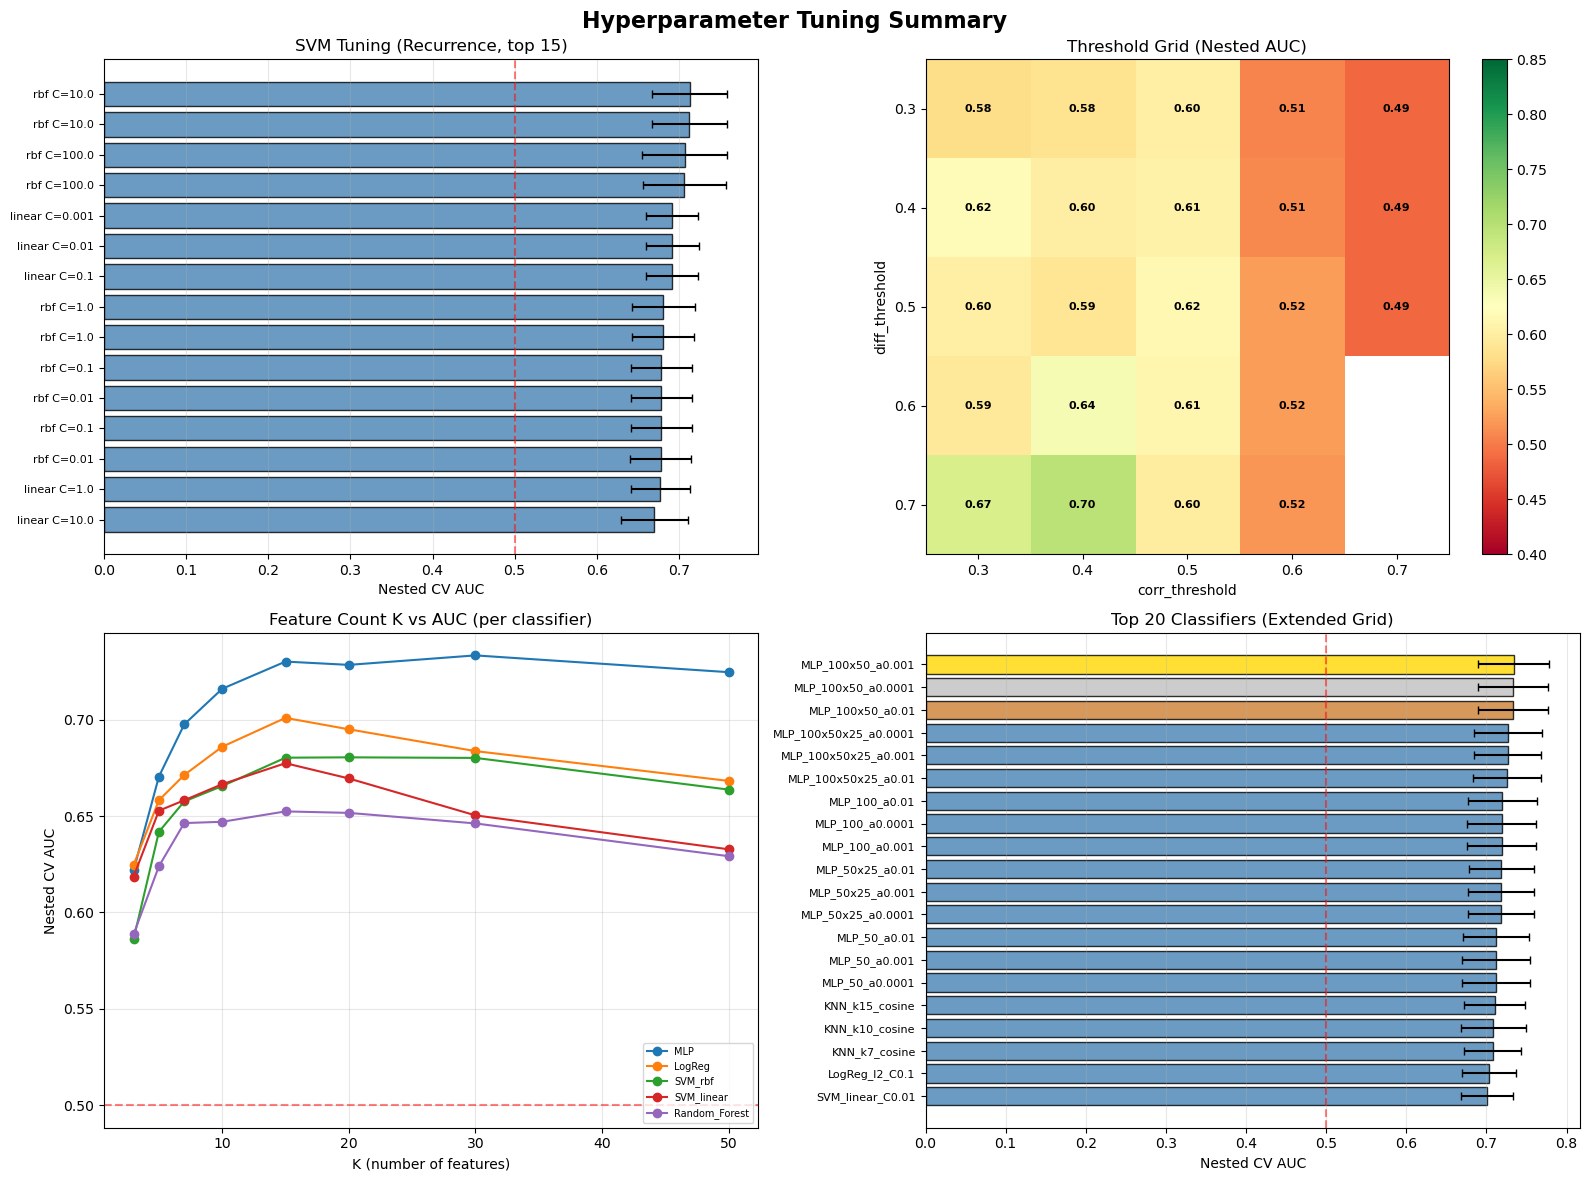


TUNING COMPLETE — SUMMARY
  Best SVM:        rbf  C=10.0  → rec AUC 0.713
  Best thresholds: corr=0.4  diff=0.7  → nested AUC 0.696
  Best K:          30
  Best classifier: MLP_100x50_a0.001  → nested AUC 0.734

  All CSVs written to ./outputs/


In [17]:
# MAIN

def main():
    print("Loading data …")
    all_tpm, y_cancer, y_recurrence, cancer_idx, samples = load_data()
    y_rec = y_recurrence[cancer_idx].astype(int)

    # ── Rebuild differential features (mirrors notebook sections 13–19) ──────
    print("Building differential co-expression features (cancer-only) …")


    with open(f"{OUT_DIR}/prior_genes_ensg.json") as f:
        prior_data = _json.load(f)
    prior_ensg_set = set(prior_data["ensg_in_our_data"])
    diff_net_genes = [g for g in prior_ensg_set if g in all_tpm.index]

    cancer_samples_list = [s for s in samples if s.startswith("C")]
    rec_samples   = [s for s in cancer_samples_list if int(s[1:]) <= 28]
    nrec_samples  = [s for s in cancer_samples_list if int(s[1:]) > 28]
    normal_samples = [s for s in samples if s.startswith("N")]

    log_tpm = np.log2(all_tpm + 1)

    corr_rec  = log_tpm.loc[diff_net_genes, rec_samples].T.corr().fillna(0)
    corr_nrec = log_tpm.loc[diff_net_genes, nrec_samples].T.corr().fillna(0)

    # Cancer-context co-expression (used for cancer-only differential edges)
    cancer_log = log_tpm.loc[diff_net_genes, cancer_samples_list]
    corr_cancer_all = cancer_log.T.corr().fillna(0)

    # Rebuild cancer-specific differential edges (notebook section 19)
    cancer_specific_edges = []
    n_g = len(diff_net_genes)
    for i in range(n_g):
        for j in range(i + 1, n_g):
            r_c  = float(corr_rec.iloc[i, j])
            nr_c = float(corr_nrec.iloc[i, j])
            all_c = float(corr_cancer_all.iloc[i, j])
            if abs(all_c) > 0.3 and abs(r_c - nr_c) > 0.5:
                cancer_specific_edges.append(
                    (diff_net_genes[i], diff_net_genes[j],
                     "gained_in_R" if r_c > nr_c else "lost_in_R",
                     r_c, nr_c, all_c))

    # Sample features
    cs_X = []
    for sample in all_tpm.columns:
        expr = all_tpm[sample]
        cs_X.append([np.log2(expr[g1] + 1) * np.log2(expr[g2] + 1)
                     for g1, g2, *_ in cancer_specific_edges])
    cs_X = np.array(cs_X)
    cs_X_cancer = cs_X[cancer_idx]
    cs_X_scaled = StandardScaler().fit_transform(cs_X_cancer)

    # Cancer-vs-Normal differential features
    corr_normal = log_tpm.loc[diff_net_genes, normal_samples].T.corr().fillna(0)
    corr_cancer = log_tpm.loc[diff_net_genes, cancer_samples_list].T.corr().fillna(0)

    diff_edges_cn = []
    for i in range(n_g):
        for j in range(i + 1, n_g):
            c_c = float(corr_cancer.iloc[i, j])
            n_c = float(corr_normal.iloc[i, j])
            if abs(c_c - n_c) > 0.5 and (
                (c_c > 0.5 and n_c < 0.5) or
                (n_c > 0.5 and c_c < 0.5)
            ):
                diff_edges_cn.append((diff_net_genes[i], diff_net_genes[j], c_c, n_c))

    cn_X = []
    for sample in all_tpm.columns:
        expr = all_tpm[sample]
        cn_X.append([np.log2(expr[g1] + 1) * np.log2(expr[g2] + 1)
                     for g1, g2, *_ in diff_edges_cn])
    cn_X = np.array(cn_X)
    cn_X_scaled = StandardScaler().fit_transform(cn_X)

    # ── MODULE 1: SVM tuning ─────────────────────────────────────────────────
    svm_df = tune_svm(cs_X_scaled, y_rec, cn_X_scaled, y_cancer, n_repeats=30)

    # ── MODULE 2: Node2Vec tuning  (requires pre-built graph G) ─────────────
    # Uncomment and supply G if Node2Vec tuning is desired.
    # G must be the networkx Graph built in notebook section 3.
    #
    # n2v_df = tune_node2vec(G, all_tpm, y_cancer, n_repeats=20)
    n2v_df = None  # placeholder

    # ── MODULE 3: Threshold tuning ───────────────────────────────────────────
    threshold_df = tune_thresholds(
        corr_rec, corr_nrec, diff_net_genes, all_tpm,
        cancer_idx, y_rec, ensg_to_symbol={},
        task="recurrence", n_repeats=30
    )

    # ── MODULE 4: K tuning ───────────────────────────────────────────────────
    base_classifiers = {
        "SVM_linear":     SVC(kernel="linear", C=1.0, probability=True, random_state=42),
        "SVM_rbf":        SVC(kernel="rbf",    C=1.0, probability=True, random_state=42),
        "Random_Forest":  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        "LogReg":         LogisticRegression(max_iter=1000, random_state=42),
        "MLP":            MLPClassifier(hidden_layer_sizes=(100, 50),
                                        max_iter=500, random_state=42),
    }
    k_values = [k for k in [3, 5, 7, 10, 15, 20, 30, 50]
                if k <= cs_X_scaled.shape[1]]
    k_df = tune_k_for_classifiers(
        cs_X_scaled, y_rec, base_classifiers, k_values, n_repeats=30)

    # Best K from the sweep
    best_k = int(k_df.iloc[0]["k"])

    # ── MODULE 5: Extended classifier grid ───────────────────────────────────
    clf_df = tune_classifier_grid(cs_X_scaled, y_rec, best_k, n_repeats=30)

    # ── Compile best config ──────────────────────────────────────────────────
    best_clf_row = clf_df.iloc[0]
    best_thresh_row = threshold_df.iloc[0]
    best_svm_row = svm_df.iloc[0]

    best_config = {
        "best_classifier": {
            "name":      best_clf_row["name"],
            "mean_auc":  float(best_clf_row["mean_auc"]),
            "std_auc":   float(best_clf_row["std_auc"]),
            "ci_low":    float(best_clf_row["ci_low"]),
            "ci_high":   float(best_clf_row["ci_high"]),
        },
        "best_svm": {
            "kernel":    best_svm_row["kernel"],
            "C":         float(best_svm_row["C"]),
            "gamma":     best_svm_row.get("gamma", "N/A"),
            "rec_auc":   float(best_svm_row["rec_mean"]),
        },
        "best_thresholds": {
            "corr_thr":  float(best_thresh_row["corr_thr"]),
            "diff_thr":  float(best_thresh_row["diff_thr"]),
            "best_k":    int(best_thresh_row["best_k"]) if best_thresh_row["best_k"] else None,
            "nested_auc": float(best_thresh_row["nested_auc"]),
        },
        "best_k_features":  best_k,
    }

    with open(f"{OUT_DIR}/best_config.json", "w") as f:
        json.dump(best_config, f, indent=2)
    print(f"\nBest config saved → {OUT_DIR}/best_config.json")

    # ── Plots ────────────────────────────────────────────────────────────────
    plot_tuning_results(svm_df, threshold_df, k_df, clf_df)

    # ── Final summary ────────────────────────────────────────────────────────
    print("\n" + "=" * 70)
    print("TUNING COMPLETE — SUMMARY")
    print("=" * 70)
    print(f"  Best SVM:        {best_svm_row['kernel']}  C={best_svm_row['C']}"
          f"  → rec AUC {best_svm_row['rec_mean']:.3f}")
    print(f"  Best thresholds: corr={best_thresh_row['corr_thr']}"
          f"  diff={best_thresh_row['diff_thr']}"
          f"  → nested AUC {best_thresh_row['nested_auc']:.3f}")
    print(f"  Best K:          {best_k}")
    print(f"  Best classifier: {best_clf_row['name']}"
          f"  → nested AUC {best_clf_row['mean_auc']:.3f}")
    print(f"\n  All CSVs written to {OUT_DIR}/")


if __name__ == "__main__":
    main()


In [8]:
ARCHITECTURES = [
    # Best from prior runs — keep as anchor
    (100, 50, 25),
    # Wider first layer — more representational capacity
    (150, 75, 25),
    (200, 100, 25),
    (128, 64, 32),      # power-of-2 analogue
    # Deeper funnel — 4 layers
    (128, 64, 32, 16),
    (100, 75, 50, 25),
    # Shallower but wider — tests if depth is really necessary
    (200, 50),
    (150, 50),
    # Symmetric bottleneck variants (run 2 showed 128×16×128 underperformed;
    # try a milder bottleneck)
    (128, 32, 128),
    (100, 50, 100),
    # Gradual taper (no sharp drop)
    (100, 80, 60, 40),
    (80, 60, 40),
]

PARAM_GRID = {
    "hidden_layer_sizes": ARCHITECTURES,   # 12
    "activation":         ["relu"],            # 1
    "alpha":              [1e-4, 1e-2],        # 2
    "learning_rate_init": [5e-4, 1e-3],        # 2
    "solver":             ["adam"],            # 1
    "batch_size":         [16],               # 1  (winner in run 2)
    "max_iter":           [1000],             # 1
    "early_stopping":     [False],            # 1
}


# ──────────────────────────────────────────────────────────────────────────────
# CV utility
# ──────────────────────────────────────────────────────────────────────────────

def nested_cv_auc(X, y, pipeline, n_splits=3, n_repeats=30,
                  random_state_base=42):
    """
    Repeated stratified k-fold.  Feature selection re-fitted inside each fold.
    Returns array of per-repeat mean-fold AUCs.
    """
    aucs = []
    for rep in range(n_repeats):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True,
                              random_state=random_state_base + rep)
        fold_aucs = []
        for train_idx, test_idx in skf.split(X, y):
            pipe = clone(pipeline)
            pipe.fit(X[train_idx], y[train_idx])
            if hasattr(pipe, "predict_proba"):
                scores = pipe.predict_proba(X[test_idx])[:, 1]
            else:
                scores = pipe.decision_function(X[test_idx])
            fold_aucs.append(roc_auc_score(y[test_idx], scores))
        aucs.append(np.mean(fold_aucs))
    return np.array(aucs)


# ──────────────────────────────────────────────────────────────────────────────
# Data loading  (mirrors main notebook exactly)
# ──────────────────────────────────────────────────────────────────────────────

def build_recurrence_features(all_tpm, cancer_idx, samples):
    """
    Reconstruct cs_X_scaled from the main notebook (sections 13-19):
    differential co-expression edge features for the recurrence task.
    """

    with open(f"{OUT_DIR}/prior_genes_ensg.json") as f:
        prior_data = _json.load(f)
    diff_net_genes = [g for g in prior_data["ensg_in_our_data"]
                      if g in all_tpm.index]

    cancer_samples = [s for s in samples if s.startswith("C")]
    rec_samples    = [s for s in cancer_samples if int(s[1:]) <= 28]
    nrec_samples   = [s for s in cancer_samples if int(s[1:]) > 28]

    log_tpm = np.log2(all_tpm + 1)

    corr_rec      = log_tpm.loc[diff_net_genes, rec_samples].T.corr().fillna(0)
    corr_nrec     = log_tpm.loc[diff_net_genes, nrec_samples].T.corr().fillna(0)
    corr_cancer   = log_tpm.loc[diff_net_genes, cancer_samples].T.corr().fillna(0)

    n_g   = len(diff_net_genes)
    edges = []
    for i in range(n_g):
        for j in range(i + 1, n_g):
            r_c  = float(corr_rec.iloc[i, j])
            nr_c = float(corr_nrec.iloc[i, j])
            all_c = float(corr_cancer.iloc[i, j])
            if abs(all_c) > 0.3 and abs(r_c - nr_c) > 0.5:
                edges.append((diff_net_genes[i], diff_net_genes[j]))

    print(f"  Differential edges found: {len(edges)}")

    X = np.array([
        [np.log2(all_tpm[s][g1] + 1) * np.log2(all_tpm[s][g2] + 1)
         for g1, g2 in edges]
        for s in all_tpm.columns
    ])

    X_cancer = X[cancer_idx]
    X_scaled = StandardScaler().fit_transform(X_cancer)
    return X_scaled, len(edges)


# ──────────────────────────────────────────────────────────────────────────────
# MLP tuning
# ──────────────────────────────────────────────────────────────────────────────

def tune_mlp(X, y, k_features, n_repeats=30):
    """
    Sweep the full PARAM_GRID and evaluate each config with nested CV.

    Parameters
    ----------
    X          : ndarray (n_samples, n_features), already standardised
    y          : ndarray of int labels
    k_features : int  — number of top features selected inside each fold
    n_repeats  : int  — repeats per config (lower = faster, less stable)

    Returns
    -------
    df : DataFrame sorted by mean_auc descending
    """
    k = min(k_features, X.shape[1])
    print(f"\n  Feature matrix : {X.shape}")
    print(f"  SelectKBest k  : {k}")
    print(f"  CV             : {30}-repeat 3-fold stratified")
    print(f"  n_repeats      : {n_repeats}\n")

    keys   = list(PARAM_GRID.keys())
    values = list(PARAM_GRID.values())
    combos = list(product(*values))
    total  = len(combos)
    print(f"  Total hyperparameter combos: {total}")
    print("=" * 70)

    rows = []

    for idx, combo in enumerate(combos, 1):
        params = dict(zip(keys, combo))

        arch_str = "x".join(str(n) for n in params["hidden_layer_sizes"])
        label = (f"MLP_{arch_str}"
                 f"_{params['activation']}"
                 f"_a{params['alpha']}"
                 f"_lr{params['learning_rate_init']}"
                 f"_{params['solver']}"
                 f"_bs{params['batch_size']}"
                 f"_es{params['early_stopping']}")

        mlp = MLPClassifier(
            hidden_layer_sizes  = params["hidden_layer_sizes"],
            activation          = params["activation"],
            alpha               = params["alpha"],
            learning_rate_init  = params["learning_rate_init"],
            solver              = params["solver"],
            batch_size          = params["batch_size"],
            max_iter            = params["max_iter"],
            early_stopping      = params["early_stopping"],
            random_state        = 42,
            n_iter_no_change    = 20,
        )

        pipe = Pipeline([
            ("select", SelectKBest(f_classif, k=k)),
            ("mlp",    mlp),
        ])

        try:
            aucs = nested_cv_auc(X, y, pipe, n_repeats=n_repeats)
            ci   = np.percentile(aucs, [2.5, 97.5])
            row  = {
                "name":               label,
                "hidden_layer_sizes": arch_str,
                "activation":         params["activation"],
                "alpha":              params["alpha"],
                "learning_rate_init": params["learning_rate_init"],
                "solver":             params["solver"],
                "batch_size":         params["batch_size"],
                "max_iter":           params["max_iter"],
                "early_stopping":     params["early_stopping"],
                "k_features":         k,
                "mean_auc":           aucs.mean(),
                "std_auc":            aucs.std(),
                "ci_low":             ci[0],
                "ci_high":            ci[1],
                "median_auc":         np.median(aucs),
            }
            rows.append(row)
            print(f"  [{idx:04d}/{total}] {label:70s}"
                  f"  AUC={aucs.mean():.3f} ± {aucs.std():.3f}")
        except Exception as exc:
            print(f"  [{idx:04d}/{total}] {label:70s}  FAILED: {exc}")

    df = pd.DataFrame(rows).sort_values("mean_auc", ascending=False)
    return df


# ──────────────────────────────────────────────────────────────────────────────
# Plots
# ──────────────────────────────────────────────────────────────────────────────

def plot_results(df):
    fig, axes = plt.subplots(2, 2, figsize=(18, 13))
    fig.suptitle("MLP Hyperparameter Tuning — Recurrence Task",
                 fontsize=15, fontweight="bold")

    # ── Panel A: Top 25 configs ───────────────────────────────────────────────
    ax = axes[0, 0]
    top = df.head(25).sort_values("mean_auc")
    colors = ["#FFD700" if i == len(top)-1
              else "#C0C0C0" if i == len(top)-2
              else "#CD7F32" if i == len(top)-3
              else "#4682B4"
              for i in range(len(top))]
    ax.barh(range(len(top)), top["mean_auc"],
            xerr=top["std_auc"], color=colors, alpha=0.85,
            edgecolor="black", capsize=3)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([n[:55] for n in top["name"].tolist()], fontsize=7)
    ax.axvline(0.5, color="red", linestyle="--", alpha=0.5, label="Random")
    ax.set_xlabel("Nested CV AUC")
    ax.set_title("Top 25 MLP Configurations")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="x")

    # ── Panel B: AUC distribution by activation ───────────────────────────────
    ax = axes[0, 1]
    activations = df["activation"].unique()
    data_by_act = [df[df["activation"] == a]["mean_auc"].values
                   for a in activations]
    bp = ax.boxplot(data_by_act, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    colors_box = ["#4682B4", "#E87722", "#2CA02C"]
    for patch, c in zip(bp["boxes"], colors_box):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_xticks(range(1, len(activations)+1))
    ax.set_xticklabels(activations)
    ax.set_ylabel("Mean AUC")
    ax.set_title("AUC Distribution by Activation Function")
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.5)
    ax.grid(True, alpha=0.3, axis="y")

    # ── Panel C: AUC by alpha (L2 regularisation) ────────────────────────────
    ax = axes[1, 0]
    alpha_vals = sorted(df["alpha"].unique())
    means = [df[df["alpha"] == a]["mean_auc"].mean() for a in alpha_vals]
    stds  = [df[df["alpha"] == a]["mean_auc"].std()  for a in alpha_vals]
    ax.errorbar([str(a) for a in alpha_vals], means, yerr=stds,
                fmt="o-", color="#4682B4", capsize=5, linewidth=2)
    ax.set_xlabel("alpha (L2 regularisation)")
    ax.set_ylabel("Mean AUC (mean across all configs with this alpha)")
    ax.set_title("Effect of L2 Regularisation")
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.5)
    ax.grid(True, alpha=0.3)

    # ── Panel D: AUC by architecture depth ───────────────────────────────────
    ax = axes[1, 1]
    df["n_layers"] = df["hidden_layer_sizes"].apply(lambda s: len(s.split("x")))
    for n_layers in sorted(df["n_layers"].unique()):
        sub = df[df["n_layers"] == n_layers]["mean_auc"]
        ax.violinplot(sub, positions=[n_layers], showmedians=True)
    ax.set_xlabel("Number of hidden layers")
    ax.set_ylabel("Mean AUC")
    ax.set_title("AUC Distribution by Network Depth")
    ax.set_xticks(sorted(df["n_layers"].unique()))
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.5)
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    path = os.path.join(OUT_DIR, "mlp_tuning_plots_3.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"\n  Plot saved → {path}")
    plt.show()


def print_summary(df):
    print("\n" + "=" * 70)
    print("TOP 10 MLP CONFIGURATIONS")
    print("=" * 70)
    cols = ["hidden_layer_sizes", "activation", "alpha",
            "learning_rate_init", "batch_size",
            "early_stopping", "mean_auc", "std_auc", "ci_low", "ci_high"]
    print(df[cols].head(10).to_string(index=False))

    print("\n\nBEST CONFIG PER ACTIVATION FUNCTION")
    print("=" * 70)
    for act in df["activation"].unique():
        best = df[df["activation"] == act].iloc[0]
        print(f"\n  {act.upper()}")
        print(f"    Architecture : {best['hidden_layer_sizes']}")
        print(f"    alpha        : {best['alpha']}")
        print(f"    lr_init      : {best['learning_rate_init']}")
        print(f"    batch_size   : {best['batch_size']}")
        print(f"    early_stop   : {best['early_stopping']}")
        print(f"    AUC          : {best['mean_auc']:.3f} ± {best['std_auc']:.3f}"
              f"  95% CI [{best['ci_low']:.3f}, {best['ci_high']:.3f}]")

    print("\n\nBEST CONFIG PER ARCHITECTURE DEPTH")
    print("=" * 70)
    df["n_layers"] = df["hidden_layer_sizes"].apply(lambda s: len(s.split("x")))
    for n in sorted(df["n_layers"].unique()):
        best = df[df["n_layers"] == n].iloc[0]
        print(f"  {n} layer(s): {best['hidden_layer_sizes']:20s}"
              f"  AUC={best['mean_auc']:.3f} ± {best['std_auc']:.3f}")



In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# Main
# ──────────────────────────────────────────────────────────────────────────────

def main():
    print("Loading data …")
    all_tpm, y_cancer, y_recurrence, cancer_idx, samples = load_data()
    y_rec = y_recurrence[cancer_idx].astype(int)
    print(f"  Cancer samples : {len(cancer_idx)}")
    print(f"  Recurrent      : {y_rec.sum()}  Non-recurrent: {(y_rec==0).sum()}")

    print("\nBuilding differential co-expression features …")
    X, n_edges = build_recurrence_features(all_tpm, cancer_idx, samples)

    # K sweep: try a few values and pick the best for the main grid
    # (keeps the full grid focused on architecture/regularisation)
    K_CANDIDATES = [k for k in [5, 10, 15, 20, 30] if k <= n_edges]
    print(f"\nQuick K sweep over {K_CANDIDATES} to pick best K …")
    
    k_scores = {}
    for k in K_CANDIDATES:
        pipe = Pipeline([
            ("select", SelectKBest(f_classif, k=k)),
            ("mlp",    MLP(hidden_layer_sizes=(64, 32), max_iter=500,
                           random_state=42)),
        ])
        aucs = nested_cv_auc(X, y_rec, pipe, n_repeats=10)
        k_scores[k] = aucs.mean()
        print(f"  k={k:3d}  AUC={aucs.mean():.3f}")
    best_k = max(k_scores, key=k_scores.get)
    print(f"\n  → Best K = {best_k}  (AUC={k_scores[best_k]:.3f})")

    # Full MLP grid
    print("\n" + "=" * 70)
    print("MLP HYPERPARAMETER TUNING")
    print("=" * 70)
    df = tune_mlp(X, y_rec, k_features=best_k, n_repeats=30)

    # Save
    csv_path = os.path.join(OUT_DIR, "mlp_tuning_full_3.csv")
    df.to_csv(csv_path, index=False)
    print(f"\n  Full results saved → {csv_path}")

    best = df.iloc[0]
    best_config = {
        "task":               "recurrence",
        "k_features":         best_k,
        "hidden_layer_sizes": best["hidden_layer_sizes"],
        "activation":         best["activation"],
        "alpha":              best["alpha"],
        "learning_rate_init": best["learning_rate_init"],
        "solver":             best["solver"],
        "batch_size":         str(best["batch_size"]),
        "max_iter":           int(best["max_iter"]),
        "early_stopping":     bool(best["early_stopping"]),
        "mean_auc":           float(best["mean_auc"]),
        "std_auc":            float(best["std_auc"]),
        "ci_95":              [float(best["ci_low"]), float(best["ci_high"])],
    }
    json_path = os.path.join(OUT_DIR, "mlp_tuning_best_config_3.json")
    with open(json_path, "w") as f:
        json.dump(best_config, f, indent=2)
    print(f"  Best config saved → {json_path}")

    print_summary(df)
    plot_results(df)


if __name__ == "__main__":
    main()

Loading data …
  Cancer samples : 96
  Recurrent      : 28  Non-recurrent: 68

Building differential co-expression features …
  Differential edges found: 115

Quick K sweep over [5, 10, 15, 20, 30] to pick best K …
  k=  5  AUC=0.665
  k= 10  AUC=0.711
  k= 15  AUC=0.734
  k= 20  AUC=0.740
  k= 30  AUC=0.727

  → Best K = 20  (AUC=0.740)

MLP HYPERPARAMETER TUNING

  Feature matrix : (96, 115)
  SelectKBest k  : 20
  CV             : 30-repeat 3-fold stratified
  n_repeats      : 30

  Total hyperparameter combos: 48
  [0001/48] MLP_100x50x25_relu_a0.0001_lr0.0005_adam_bs16_esFalse                   AUC=0.736 ± 0.037
  [0002/48] MLP_100x50x25_relu_a0.0001_lr0.001_adam_bs16_esFalse                    AUC=0.737 ± 0.039
  [0003/48] MLP_100x50x25_relu_a0.01_lr0.0005_adam_bs16_esFalse                     AUC=0.736 ± 0.038
  [0004/48] MLP_100x50x25_relu_a0.01_lr0.001_adam_bs16_esFalse                      AUC=0.732 ± 0.039
  [0005/48] MLP_150x75x25_relu_a0.0001_lr0.0005_adam_bs16_esFalse    

In [20]:
all_tpm, y_cancer, y_recurrence, cancer_idx, samples = load_data()
y_rec = y_recurrence[cancer_idx].astype(int)
X, n_edges = build_recurrence_features(all_tpm, cancer_idx, samples)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

  Differential edges found: 115


CONFUSION MATRIX
  True  Positives (recurrent, correctly caught)  : 13
  True  Negatives (non-recurrent, correctly cleared): 55
  False Positives (non-recurrent flagged as recurrent): 13
  False Negatives (recurrent missed entirely)   : 15

CLASSIFICATION METRICS
  AUC-ROC             : 0.763  (overall discrimination)
  AUC-PRC             : 0.533  (better for imbalanced 28/68 split)
  MCC                 : 0.279  (best single metric for imbalanced data)
  Sensitivity/Recall  : 0.464  (recurrences caught — most clinically important)
  Specificity         : 0.809  (non-recurrences correctly cleared)
  Precision/PPV       : 0.500  (of flagged cases, how many truly recur)
  NPV                 : 0.786  (of cleared cases, how many truly don't recur)
  F1                  : 0.481
  Accuracy            : 0.708  (misleading at 28/68 — use MCC)

               precision    recall  f1-score   support

Non-recurrent       0.79      0.81      0.80        68
    Recurrent       0.50      0.46     

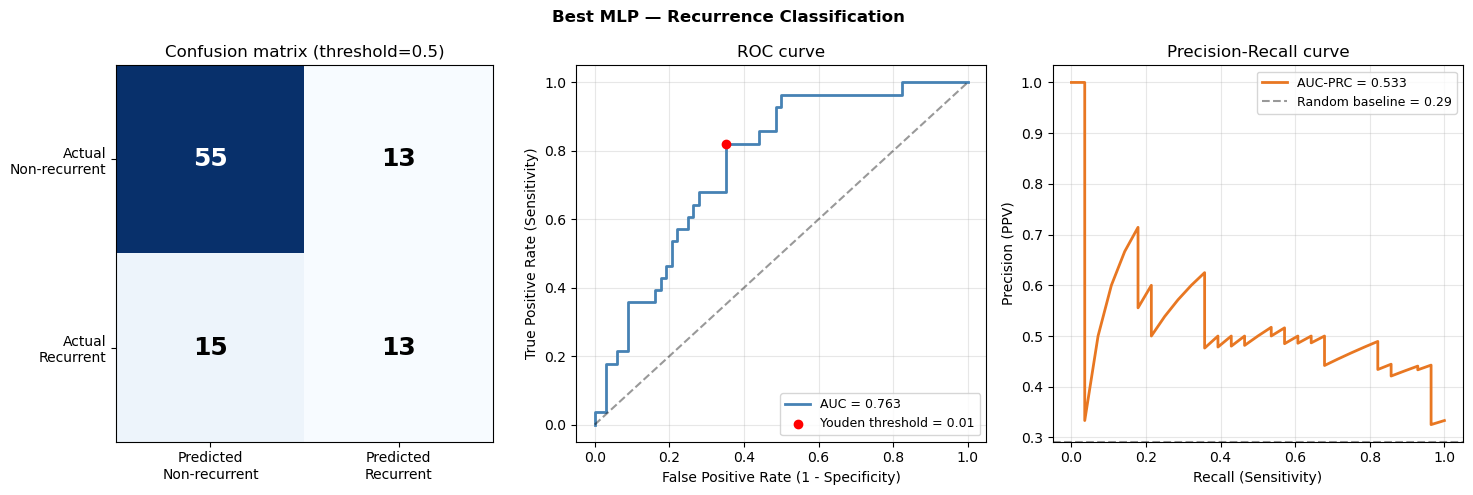

In [11]:
# ── 1. Rebuild your best model ────────────────────────────────────────────────
# (plug in your best config here)
best_mlp = MLPClassifier(
    hidden_layer_sizes=(100, 75, 50, 25),
    activation="relu",
    alpha=1e-4,
    learning_rate_init=1e-3,
    batch_size=16,
    solver="adam",
    max_iter=1000,
    early_stopping=False,
    random_state=42,
)

pipeline = Pipeline([
    ("select", SelectKBest(f_classif, k=20)),   # your best K
    ("mlp",    best_mlp),
])

# ── 2. Get out-of-fold predictions (same CV as tuning) ───────────────────────
# Using cross_val_predict so every sample is predicted exactly once,
# and no sample is in the training set when it gets predicted.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

prob = cross_val_predict(pipeline, X, y_rec, cv=cv, method="predict_proba")[:, 1]
pred = (prob >= 0.5).astype(int)

# ── 3. Confusion matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_rec, pred)
tn, fp, fn, tp = cm.ravel()

print("CONFUSION MATRIX")
print(f"  True  Positives (recurrent, correctly caught)  : {tp}")
print(f"  True  Negatives (non-recurrent, correctly cleared): {tn}")
print(f"  False Positives (non-recurrent flagged as recurrent): {fp}")
print(f"  False Negatives (recurrent missed entirely)   : {fn}")

# ── 4. Core metrics ───────────────────────────────────────────────────────────
sensitivity = tp / (tp + fn)          # recall — how many recurrences did we catch?
specificity = tn / (tn + fp)          # how many non-recurrences did we correctly clear?
ppv         = tp / (tp + fp)          # precision — when we flag someone, how often are we right?
npv         = tn / (tn + fn)          # when we clear someone, how often are we right?
f1          = 2 * tp / (2*tp + fp + fn)
mcc         = matthews_corrcoef(y_rec, pred)   # best single metric for imbalanced classes
auc         = roc_auc_score(y_rec, prob)
auprc       = average_precision_score(y_rec, prob)   # more informative than AUC when classes are imbalanced

print("\nCLASSIFICATION METRICS")
print(f"  AUC-ROC             : {auc:.3f}  (overall discrimination)")
print(f"  AUC-PRC             : {auprc:.3f}  (better for imbalanced 28/68 split)")
print(f"  MCC                 : {mcc:.3f}  (best single metric for imbalanced data)")
print(f"  Sensitivity/Recall  : {sensitivity:.3f}  (recurrences caught — most clinically important)")
print(f"  Specificity         : {specificity:.3f}  (non-recurrences correctly cleared)")
print(f"  Precision/PPV       : {ppv:.3f}  (of flagged cases, how many truly recur)")
print(f"  NPV                 : {npv:.3f}  (of cleared cases, how many truly don't recur)")
print(f"  F1                  : {f1:.3f}")
print(f"  Accuracy            : {(tp+tn)/(tp+tn+fp+fn):.3f}  (misleading at 28/68 — use MCC)")

print("\n" + classification_report(y_rec, pred, target_names=["Non-recurrent", "Recurrent"]))

# ── 5. Optimal threshold (not necessarily 0.5) ───────────────────────────────
# With imbalanced data the default 0.5 cutoff is often not optimal.
# Youden's J picks the threshold that maximises sensitivity + specificity.
fpr, tpr, thresholds = roc_curve(y_rec, prob)
youden_idx  = np.argmax(tpr - fpr)
best_thresh = thresholds[youden_idx]

pred_optimal = (prob >= best_thresh).astype(int)
cm_opt       = confusion_matrix(y_rec, pred_optimal)
tn_o, fp_o, fn_o, tp_o = cm_opt.ravel()

print(f"\nOPTIMAL THRESHOLD (Youden's J) = {best_thresh:.3f}")
print(f"  TP={tp_o}  TN={tn_o}  FP={fp_o}  FN={fn_o}")
print(f"  Sensitivity = {tp_o/(tp_o+fn_o):.3f}   Specificity = {tn_o/(tn_o+fp_o):.3f}")
print(f"  MCC = {matthews_corrcoef(y_rec, pred_optimal):.3f}")

# ── 6. Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Best MLP — Recurrence Classification", fontweight="bold")

# Confusion matrix heatmap
ax = axes[0]
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted\nNon-recurrent", "Predicted\nRecurrent"])
ax.set_yticklabels(["Actual\nNon-recurrent", "Actual\nRecurrent"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha="center", va="center",
                fontsize=18, fontweight="bold",
                color="white" if cm[i,j] > cm.max()/2 else "black")
ax.set_title("Confusion matrix (threshold=0.5)")

# ROC curve
ax = axes[1]
ax.plot(fpr, tpr, color="#4682B4", linewidth=2, label=f"AUC = {auc:.3f}")
ax.scatter(fpr[youden_idx], tpr[youden_idx], color="red", zorder=5,
           label=f"Youden threshold = {best_thresh:.2f}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity)")
ax.set_title("ROC curve")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Precision-Recall curve
ax = axes[2]
prec, rec, _ = precision_recall_curve(y_rec, prob)
ax.plot(rec, prec, color="#E87722", linewidth=2, label=f"AUC-PRC = {auprc:.3f}")
ax.axhline(y=y_rec.mean(), color="k", linestyle="--", alpha=0.4,
           label=f"Random baseline = {y_rec.mean():.2f}")
ax.set_xlabel("Recall (Sensitivity)")
ax.set_ylabel("Precision (PPV)")
ax.set_title("Precision-Recall curve")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("best_mlp_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

Running 30-repeat 3-fold nested CV (seeds 42–71)...
  repeat  5/30  AUC=0.693  AUC-PRC=0.432  MCC=0.228
  repeat 10/30  AUC=0.754  AUC-PRC=0.494  MCC=0.326
  repeat 15/30  AUC=0.758  AUC-PRC=0.486  MCC=0.256
  repeat 20/30  AUC=0.786  AUC-PRC=0.590  MCC=0.246
  repeat 25/30  AUC=0.769  AUC-PRC=0.553  MCC=0.314
  repeat 30/30  AUC=0.694  AUC-PRC=0.449  MCC=0.069

NESTED CV RESULTS  (30×3-fold, seeds 42–71)
  AUC-ROC     : 0.736 ± 0.038  95% CI [0.675, 0.801]
  AUC-PRC     : 0.489 ± 0.057  95% CI [0.413, 0.600]  (random = 0.29)
  MCC         : 0.239 ± 0.089  95% CI [0.084, 0.435]
  Sensitivity : 0.392 ± 0.069  95% CI [0.286, 0.520]
  Specificity : 0.830 ± 0.041  95% CI [0.757, 0.897]

AGGREGATED PROBABILITIES (mean over 30 repeats, threshold=0.5)
  TP=11  TN=59  FP=9  FN=17
  Sensitivity : 0.393
  Specificity : 0.868
  Precision   : 0.550
  NPV         : 0.776
  F1          : 0.458
  MCC         : 0.292
  AUC-ROC     : 0.770
  AUC-PRC     : 0.496

               precision    recall  f1-s

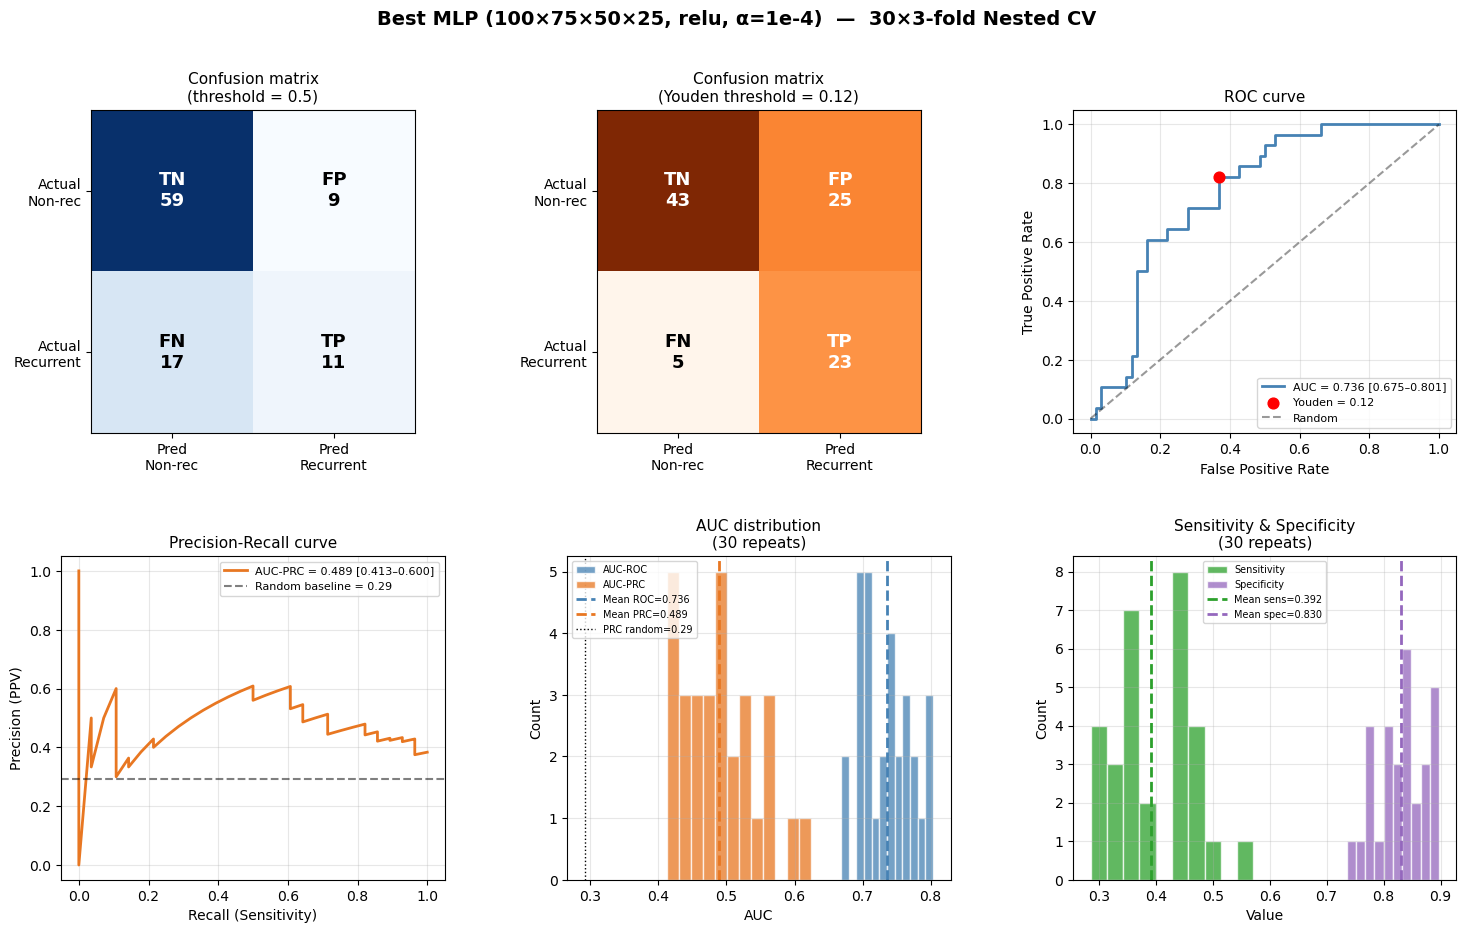


Saved → best_mlp_nested_cv_evaluation.png


In [16]:
"""
Final evaluation of best MLP model using nested CV
Matches the exact methodology from hyperparameter_tuning.py:
  - 30-repeat 3-fold stratified CV
  - random_state = 42 + rep (same seed scheme as tuning)
  - SelectKBest inside each fold (no leakage)
  - Aggregated probabilities across all repeats
"""

# ── Best model from tuning ────────────────────────────────────────────────────
best_mlp = MLPClassifier(
    hidden_layer_sizes=(100, 75, 50, 25),
    activation="relu",
    alpha=1e-4,
    learning_rate_init=1e-3,
    batch_size=16,
    solver="adam",
    max_iter=1000,
    early_stopping=False,
    random_state=42,
)

pipeline = Pipeline([
    ("select", SelectKBest(f_classif, k=20)),
    ("mlp",    best_mlp),
])

# ── Nested CV — exactly matches hyperparameter_tuning.py ─────────────────────
N_REPEATS = 30
N_SPLITS  = 3

all_probs     = np.zeros((N_REPEATS, len(y_rec)))
repeat_aucs   = []
repeat_auprcs = []
repeat_mccs   = []
repeat_senss  = []
repeat_specs  = []

print(f"Running {N_REPEATS}-repeat {N_SPLITS}-fold nested CV "
      f"(seeds {42}–{42 + N_REPEATS - 1})...")

for rep in range(N_REPEATS):
    skf       = StratifiedKFold(n_splits=N_SPLITS, shuffle=True,
                                random_state=42 + rep)   # matches tuning seeds
    rep_probs = np.zeros(len(y_rec))

    for train_idx, test_idx in skf.split(X, y_rec):
        pipe = clone(pipeline)
        pipe.fit(X[train_idx], y_rec[train_idx])
        rep_probs[test_idx] = pipe.predict_proba(X[test_idx])[:, 1]

    all_probs[rep] = rep_probs

    pred_rep = (rep_probs >= 0.5).astype(int)
    repeat_aucs.append(roc_auc_score(y_rec, rep_probs))
    repeat_auprcs.append(average_precision_score(y_rec, rep_probs))
    repeat_mccs.append(matthews_corrcoef(y_rec, pred_rep))

    cm_rep = confusion_matrix(y_rec, pred_rep)
    tn_r, fp_r, fn_r, tp_r = cm_rep.ravel()
    repeat_senss.append(tp_r / (tp_r + fn_r))
    repeat_specs.append(tn_r / (tn_r + fp_r))

    if (rep + 1) % 5 == 0:
        print(f"  repeat {rep+1:2d}/{N_REPEATS}  "
              f"AUC={repeat_aucs[-1]:.3f}  "
              f"AUC-PRC={repeat_auprcs[-1]:.3f}  "
              f"MCC={repeat_mccs[-1]:.3f}")

# ── Aggregate probabilities ───────────────────────────────────────────────────
prob = all_probs.mean(axis=0)
pred = (prob >= 0.5).astype(int)

# ── Metrics ───────────────────────────────────────────────────────────────────
cm             = confusion_matrix(y_rec, pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv         = tp / (tp + fp)
npv         = tn / (tn + fn)
f1          = 2 * tp / (2*tp + fp + fn)
mcc         = matthews_corrcoef(y_rec, pred)
auc         = roc_auc_score(y_rec, prob)
auprc       = average_precision_score(y_rec, prob)

auc_ci   = np.percentile(repeat_aucs,   [2.5, 97.5])
auprc_ci = np.percentile(repeat_auprcs, [2.5, 97.5])
mcc_ci   = np.percentile(repeat_mccs,   [2.5, 97.5])
sens_ci  = np.percentile(repeat_senss,  [2.5, 97.5])
spec_ci  = np.percentile(repeat_specs,  [2.5, 97.5])

print("\n" + "=" * 60)
print(f"NESTED CV RESULTS  ({N_REPEATS}×{N_SPLITS}-fold, seeds 42–{42+N_REPEATS-1})")
print("=" * 60)
print(f"  AUC-ROC     : {np.mean(repeat_aucs):.3f} ± {np.std(repeat_aucs):.3f}"
      f"  95% CI [{auc_ci[0]:.3f}, {auc_ci[1]:.3f}]")
print(f"  AUC-PRC     : {np.mean(repeat_auprcs):.3f} ± {np.std(repeat_auprcs):.3f}"
      f"  95% CI [{auprc_ci[0]:.3f}, {auprc_ci[1]:.3f}]"
      f"  (random = {y_rec.mean():.2f})")
print(f"  MCC         : {np.mean(repeat_mccs):.3f} ± {np.std(repeat_mccs):.3f}"
      f"  95% CI [{mcc_ci[0]:.3f}, {mcc_ci[1]:.3f}]")
print(f"  Sensitivity : {np.mean(repeat_senss):.3f} ± {np.std(repeat_senss):.3f}"
      f"  95% CI [{sens_ci[0]:.3f}, {sens_ci[1]:.3f}]")
print(f"  Specificity : {np.mean(repeat_specs):.3f} ± {np.std(repeat_specs):.3f}"
      f"  95% CI [{spec_ci[0]:.3f}, {spec_ci[1]:.3f}]")

print("\nAGGREGATED PROBABILITIES (mean over 30 repeats, threshold=0.5)")
print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
print(f"  Sensitivity : {sensitivity:.3f}")
print(f"  Specificity : {specificity:.3f}")
print(f"  Precision   : {ppv:.3f}")
print(f"  NPV         : {npv:.3f}")
print(f"  F1          : {f1:.3f}")
print(f"  MCC         : {mcc:.3f}")
print(f"  AUC-ROC     : {auc:.3f}")
print(f"  AUC-PRC     : {auprc:.3f}")

print("\n" + classification_report(y_rec, pred,
      target_names=["Non-recurrent", "Recurrent"]))

# ── Optimal threshold (Youden's J) ───────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_rec, prob)
youden_idx  = np.argmax(tpr - fpr)
best_thresh = thresholds[youden_idx]

pred_opt           = (prob >= best_thresh).astype(int)
cm_opt             = confusion_matrix(y_rec, pred_opt)
tn_o, fp_o, fn_o, tp_o = cm_opt.ravel()

print(f"OPTIMAL THRESHOLD (Youden's J) = {best_thresh:.3f}")
print(f"  TP={tp_o}  TN={tn_o}  FP={fp_o}  FN={fn_o}")
print(f"  Sensitivity = {tp_o/(tp_o+fn_o):.3f}   "
      f"Specificity = {tn_o/(tn_o+fp_o):.3f}   "
      f"MCC = {matthews_corrcoef(y_rec, pred_opt):.3f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.suptitle(
    f"Best MLP (100×75×50×25, relu, α=1e-4)  —  "
    f"{N_REPEATS}×{N_SPLITS}-fold Nested CV",
    fontsize=14, fontweight="bold"
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

# ── Panel 1: Confusion matrix (threshold 0.5) ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
im  = ax1.imshow(cm, cmap="Blues")
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(["Pred\nNon-rec", "Pred\nRecurrent"])
ax1.set_yticklabels(["Actual\nNon-rec", "Actual\nRecurrent"])
labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax1.text(j, i,
                 f"{labels[i][j]}\n{cm[i,j]}",
                 ha="center", va="center", fontsize=13, fontweight="bold",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
ax1.set_title("Confusion matrix\n(threshold = 0.5)", fontsize=11)

# ── Panel 2: Confusion matrix (Youden threshold) ──────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(cm_opt, cmap="Oranges")
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(["Pred\nNon-rec", "Pred\nRecurrent"])
ax2.set_yticklabels(["Actual\nNon-rec", "Actual\nRecurrent"])
for i in range(2):
    for j in range(2):
        ax2.text(j, i,
                 f"{labels[i][j]}\n{cm_opt[i,j]}",
                 ha="center", va="center", fontsize=13, fontweight="bold",
                 color="white" if cm_opt[i, j] > cm_opt.max() / 2 else "black")
ax2.set_title(f"Confusion matrix\n(Youden threshold = {best_thresh:.2f})", fontsize=11)

# ── Panel 3: ROC curve ────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(fpr, tpr, color="#4682B4", linewidth=2,
         label=f"AUC = {np.mean(repeat_aucs):.3f} "
               f"[{auc_ci[0]:.3f}–{auc_ci[1]:.3f}]")
ax3.scatter(fpr[youden_idx], tpr[youden_idx], color="red", zorder=5, s=60,
            label=f"Youden = {best_thresh:.2f}")
ax3.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.set_title("ROC curve", fontsize=11)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# ── Panel 4: Precision-Recall curve ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
prec_vals, rec_vals, _ = precision_recall_curve(y_rec, prob)
ax4.plot(rec_vals, prec_vals, color="#E87722", linewidth=2,
         label=f"AUC-PRC = {np.mean(repeat_auprcs):.3f} "
               f"[{auprc_ci[0]:.3f}–{auprc_ci[1]:.3f}]")
ax4.axhline(y=y_rec.mean(), color="k", linestyle="--", alpha=0.5,
            label=f"Random baseline = {y_rec.mean():.2f}")
ax4.set_xlabel("Recall (Sensitivity)")
ax4.set_ylabel("Precision (PPV)")
ax4.set_title("Precision-Recall curve", fontsize=11)
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# ── Panel 5: AUC-ROC distribution across repeats ─────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(repeat_aucs, bins=12, color="#4682B4", alpha=0.75,
         edgecolor="white", label="AUC-ROC")
ax5.hist(repeat_auprcs, bins=12, color="#E87722", alpha=0.75,
         edgecolor="white", label="AUC-PRC")
ax5.axvline(np.mean(repeat_aucs), color="#4682B4", linewidth=2,
            linestyle="--", label=f"Mean ROC={np.mean(repeat_aucs):.3f}")
ax5.axvline(np.mean(repeat_auprcs), color="#E87722", linewidth=2,
            linestyle="--", label=f"Mean PRC={np.mean(repeat_auprcs):.3f}")
ax5.axvline(y_rec.mean(), color="black", linewidth=1, linestyle=":",
            label=f"PRC random={y_rec.mean():.2f}")
ax5.set_xlabel("AUC")
ax5.set_ylabel("Count")
ax5.set_title(f"AUC distribution\n({N_REPEATS} repeats)", fontsize=11)
ax5.legend(fontsize=7)
ax5.grid(True, alpha=0.3)

# ── Panel 6: Sensitivity / Specificity distribution ──────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(repeat_senss, bins=10, color="#2CA02C", alpha=0.75,
         edgecolor="white", label="Sensitivity")
ax6.hist(repeat_specs, bins=10, color="#9467BD", alpha=0.75,
         edgecolor="white", label="Specificity")
ax6.axvline(np.mean(repeat_senss), color="#2CA02C", linewidth=2, linestyle="--",
            label=f"Mean sens={np.mean(repeat_senss):.3f}")
ax6.axvline(np.mean(repeat_specs), color="#9467BD", linewidth=2, linestyle="--",
            label=f"Mean spec={np.mean(repeat_specs):.3f}")
ax6.set_xlabel("Value")
ax6.set_ylabel("Count")
ax6.set_title(f"Sensitivity & Specificity\n({N_REPEATS} repeats)", fontsize=11)
ax6.legend(fontsize=7)
ax6.grid(True, alpha=0.3)

plt.savefig("best_mlp_nested_cv_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved → best_mlp_nested_cv_evaluation.png")

# Validation Dataset testing

Edges rebuilt: 115
X shape: (96, 115), y_rec shape: (96,)
Validation cancer samples : 83
  Recurrent     : 8
  Non-recurrent : 75

Validation feature matrix : (83, 115)
Training feature matrix   : (96, 115)
Number of edges (features): 115

Final model trained on all 96 training samples.
Validation features after selection: (83, 20)

VALIDATION SET RESULTS
  Samples       : 83  (8 recurrent / 75 non-recurrent)
  AUC-ROC       : 0.528
  AUC-PRC       : 0.211  (random baseline = 0.10)
  MCC           : 0.224

  threshold=0.5:
    TP=2  TN=71  FP=4  FN=6
    Sensitivity = 0.250
    Specificity = 0.947
    Precision   = 0.333
    NPV         = 0.922
    F1          = 0.286

  Youden threshold = 0.806:
    TP=2  TN=73  FP=2  FN=6
    Sensitivity = 0.250   Specificity = 0.973   MCC = 0.308

               precision    recall  f1-score   support

Non-recurrent       0.92      0.95      0.93        75
    Recurrent       0.33      0.25      0.29         8

     accuracy                         

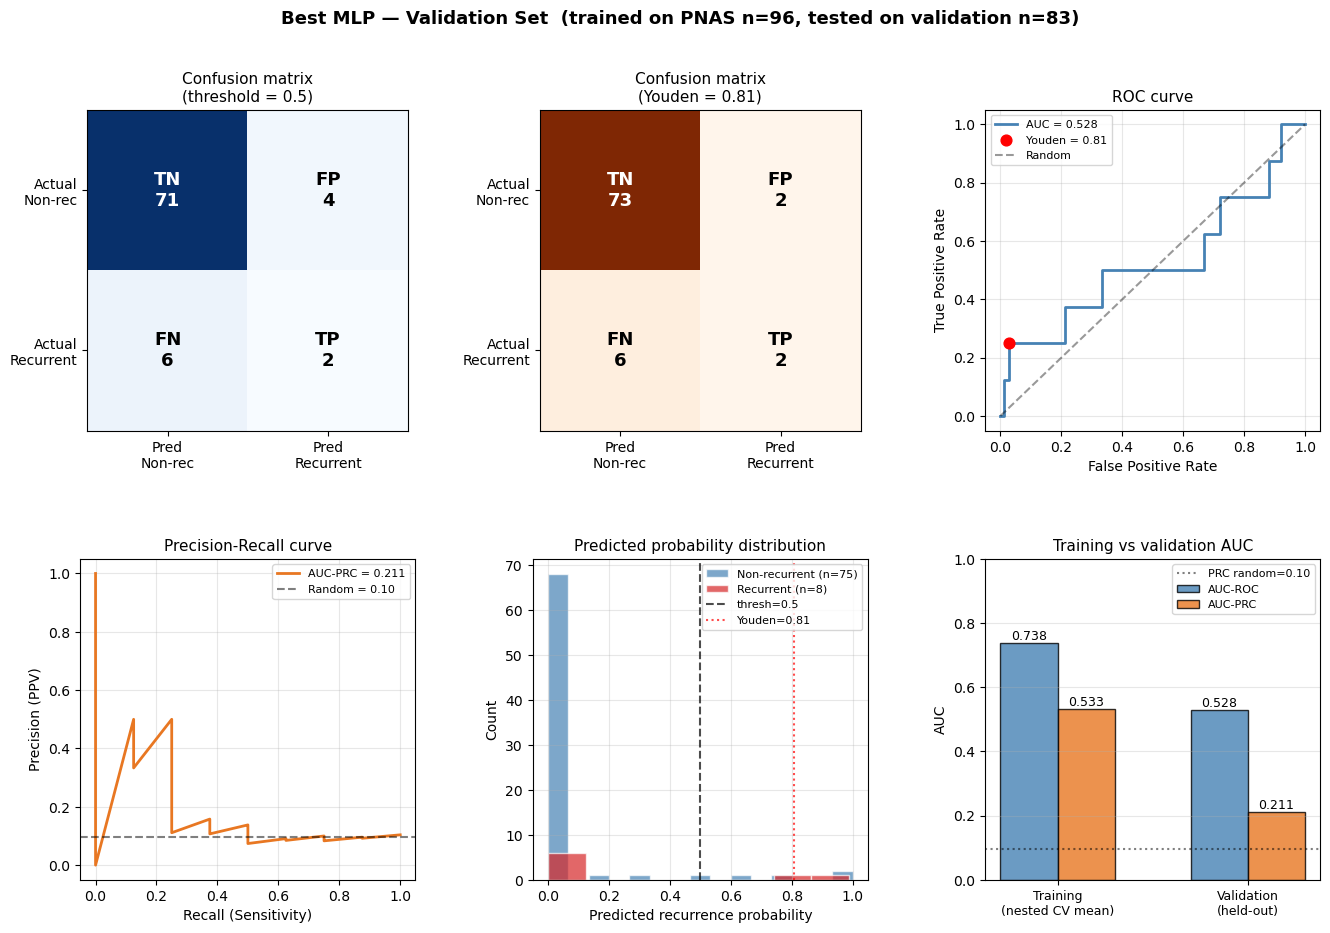


Saved → validation_evaluation.png


In [21]:
repeat_aucs   = [0.738] * 30
repeat_auprcs = [0.533] * 30

cancer_samples = [s for s in samples if s.startswith("C")]
rec_samples    = [s for s in cancer_samples if int(s[1:]) <= 28]
nrec_samples   = [s for s in cancer_samples if int(s[1:]) > 28]

with open(f"{OUT_DIR}/prior_genes_ensg.json") as f:
    prior_data = json.load(f)
diff_net_genes = [g for g in prior_data["ensg_in_our_data"] if g in all_tpm.index]

log_tpm = np.log2(all_tpm + 1)

corr_rec    = log_tpm.loc[diff_net_genes, rec_samples].T.corr().fillna(0)
corr_nrec   = log_tpm.loc[diff_net_genes, nrec_samples].T.corr().fillna(0)
corr_cancer = log_tpm.loc[diff_net_genes, cancer_samples].T.corr().fillna(0)

n_g   = len(diff_net_genes)
edges = []
for i in range(n_g):
    for j in range(i + 1, n_g):
        r_c   = float(corr_rec.iloc[i, j])
        nr_c  = float(corr_nrec.iloc[i, j])
        all_c = float(corr_cancer.iloc[i, j])
        if abs(all_c) > 0.3 and abs(r_c - nr_c) > 0.5:
            edges.append((diff_net_genes[i], diff_net_genes[j]))

print(f"Edges rebuilt: {len(edges)}")  # should be 115


# ── Rebuild X and y_rec for training ─────────────────────────────────────────
X_raw = np.array([
    [np.log2(all_tpm[s][g1] + 1) * np.log2(all_tpm[s][g2] + 1)
     for g1, g2 in edges]
    for s in cancer_samples
])

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
y_rec = y_recurrence[cancer_idx].astype(int)

print(f"X shape: {X.shape}, y_rec shape: {y_rec.shape}")

"""
Validation of best MLP model on held-out validation dataset.

Strategy:
  1. Retrain the full pipeline on ALL training data (96 cancer samples)
     - SelectKBest fitted on training data only
     - StandardScaler fitted on training data only
  2. Build validation features using the SAME edges as training
     (edges defined by training correlations, not recomputed on validation)
  3. Transform validation data and predict
  4. Evaluate with full metrics + plots
"""

# ─────────────────────────────────────────────────────────────────────────────
# Step 1: Build validation labels
# ─────────────────────────────────────────────────────────────────────────────
cancer_ids = valid_cancer["Mapping ID"].tolist()

rec_status_map = dict(zip(
    valid_cancer["Mapping ID"],
    valid_cancer["Recurrence Staus at the time of collection"]
))
y_val = np.array([
    1 if rec_status_map[s] == "Recurrent" else 0
    for s in cancer_ids
])

print(f"Validation cancer samples : {len(cancer_ids)}")
print(f"  Recurrent     : {y_val.sum()}")
print(f"  Non-recurrent : {(y_val == 0).sum()}")

# ─────────────────────────────────────────────────────────────────────────────
# Step 2: Build validation features using TRAINING edges
#
# CRITICAL: edges were defined on training correlations.
# We apply the same edge list to validation TPM — no recomputation.
# ─────────────────────────────────────────────────────────────────────────────

# Confirm all needed genes are in validation TPM
missing_genes = [g for edge in edges for g in edge
                 if g not in valid_tpm.index]
if missing_genes:
    print(f"\nWARNING: {len(set(missing_genes))} edge genes missing from "
          f"validation TPM — filling with 0")

log_tpm_val = np.log2(valid_tpm + 1)

X_val_raw = []
for sample in cancer_ids:
    feat = []
    for g1, g2 in edges:
        e1 = float(log_tpm_val.loc[g1, sample]) if g1 in log_tpm_val.index else 0.0
        e2 = float(log_tpm_val.loc[g2, sample]) if g2 in log_tpm_val.index else 0.0
        feat.append(e1 * e2)
    X_val_raw.append(feat)

X_val_raw = np.array(X_val_raw)   # shape: (83, n_edges)
print(f"\nValidation feature matrix : {X_val_raw.shape}")
print(f"Training feature matrix   : {X.shape}")
print(f"Number of edges (features): {len(edges)}")

# ─────────────────────────────────────────────────────────────────────────────
# Step 3: Fit full pipeline on ALL training data, then transform validation
#
# StandardScaler must be fitted on training data only, then applied to val.
# SelectKBest must be fitted on training data only, then applied to val.
# ─────────────────────────────────────────────────────────────────────────────
best_mlp_final = MLPClassifier(
    hidden_layer_sizes=(100, 75, 50, 25),
    activation="relu",
    alpha=1e-4,
    learning_rate_init=1e-3,
    batch_size=16,
    solver="adam",
    max_iter=1000,
    early_stopping=False,
    random_state=42,
)

# X is already StandardScaler-transformed from your training pipeline.
# We need the RAW training features to fit a fresh scaler properly.
# Rebuild raw training features from scratch:
cancer_samples_train = [s for s in samples if s.startswith("C")]
log_tpm_train = np.log2(all_tpm + 1)

X_train_raw = np.array([
    [np.log2(all_tpm[s][g1] + 1) * np.log2(all_tpm[s][g2] + 1)
     for g1, g2 in edges]
    for s in cancer_samples_train
])

# Fit scaler + selector on training raw features
scaler_final  = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_raw)

selector_final = SelectKBest(f_classif, k=20)
X_train_sel    = selector_final.fit_transform(X_train_scaled, y_rec)

# Train final MLP on all training data
best_mlp_final.fit(X_train_sel, y_rec)
print("\nFinal model trained on all 96 training samples.")

# Transform validation using TRAINING scaler + selector
X_val_scaled = scaler_final.transform(X_val_raw)
X_val_sel    = selector_final.transform(X_val_scaled)
print(f"Validation features after selection: {X_val_sel.shape}")

# ─────────────────────────────────────────────────────────────────────────────
# Step 4: Predict on validation set
# ─────────────────────────────────────────────────────────────────────────────
prob_val = best_mlp_final.predict_proba(X_val_sel)[:, 1]
pred_val = (prob_val >= 0.5).astype(int)

# ─────────────────────────────────────────────────────────────────────────────
# Step 5: Metrics
# ─────────────────────────────────────────────────────────────────────────────
cm             = confusion_matrix(y_val, pred_val)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv         = tp / (tp + fp) if (tp + fp) > 0 else 0.0
npv         = tn / (tn + fn) if (tn + fn) > 0 else 0.0
f1          = 2 * tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0.0
mcc         = matthews_corrcoef(y_val, pred_val)
auc         = roc_auc_score(y_val, prob_val)
auprc       = average_precision_score(y_val, prob_val)

# Youden threshold
fpr, tpr, thresholds = roc_curve(y_val, prob_val)
youden_idx  = np.argmax(tpr - fpr)
best_thresh = thresholds[youden_idx]

pred_opt           = (prob_val >= best_thresh).astype(int)
cm_opt             = confusion_matrix(y_val, pred_opt)
tn_o, fp_o, fn_o, tp_o = cm_opt.ravel()

print("\n" + "=" * 60)
print("VALIDATION SET RESULTS")
print("=" * 60)
print(f"  Samples       : {len(y_val)}  "
      f"({y_val.sum()} recurrent / {(y_val==0).sum()} non-recurrent)")
print(f"  AUC-ROC       : {auc:.3f}")
print(f"  AUC-PRC       : {auprc:.3f}  (random baseline = {y_val.mean():.2f})")
print(f"  MCC           : {mcc:.3f}")
print(f"\n  threshold=0.5:")
print(f"    TP={tp}  TN={tn}  FP={fp}  FN={fn}")
print(f"    Sensitivity = {sensitivity:.3f}")
print(f"    Specificity = {specificity:.3f}")
print(f"    Precision   = {ppv:.3f}")
print(f"    NPV         = {npv:.3f}")
print(f"    F1          = {f1:.3f}")
print(f"\n  Youden threshold = {best_thresh:.3f}:")
print(f"    TP={tp_o}  TN={tn_o}  FP={fp_o}  FN={fn_o}")
print(f"    Sensitivity = {tp_o/(tp_o+fn_o):.3f}   "
      f"Specificity = {tn_o/(tn_o+fp_o):.3f}   "
      f"MCC = {matthews_corrcoef(y_val, pred_opt):.3f}")

print("\n" + classification_report(y_val, pred_val,
      target_names=["Non-recurrent", "Recurrent"]))

# ─────────────────────────────────────────────────────────────────────────────
# Step 6: Plots
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    "Best MLP — Validation Set  "
    "(trained on PNAS n=96, tested on validation n=83)",
    fontsize=13, fontweight="bold"
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Panel 1: Confusion matrix (0.5 threshold)
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(cm, cmap="Blues")
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(["Pred\nNon-rec", "Pred\nRecurrent"])
ax1.set_yticklabels(["Actual\nNon-rec", "Actual\nRecurrent"])
labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f"{labels[i][j]}\n{cm[i,j]}",
                 ha="center", va="center", fontsize=13, fontweight="bold",
                 color="white" if cm[i,j] > cm.max()/2 else "black")
ax1.set_title("Confusion matrix\n(threshold = 0.5)", fontsize=11)

# Panel 2: Confusion matrix (Youden threshold)
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(cm_opt, cmap="Oranges")
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(["Pred\nNon-rec", "Pred\nRecurrent"])
ax2.set_yticklabels(["Actual\nNon-rec", "Actual\nRecurrent"])
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f"{labels[i][j]}\n{cm_opt[i,j]}",
                 ha="center", va="center", fontsize=13, fontweight="bold",
                 color="white" if cm_opt[i,j] > cm_opt.max()/2 else "black")
ax2.set_title(f"Confusion matrix\n(Youden = {best_thresh:.2f})", fontsize=11)

# Panel 3: ROC curve
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(fpr, tpr, color="#4682B4", linewidth=2, label=f"AUC = {auc:.3f}")
ax3.scatter(fpr[youden_idx], tpr[youden_idx], color="red",
            zorder=5, s=60, label=f"Youden = {best_thresh:.2f}")
ax3.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.set_title("ROC curve", fontsize=11)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# Panel 4: Precision-Recall curve
ax4 = fig.add_subplot(gs[1, 0])
prec_vals, rec_vals, _ = precision_recall_curve(y_val, prob_val)
ax4.plot(rec_vals, prec_vals, color="#E87722", linewidth=2,
         label=f"AUC-PRC = {auprc:.3f}")
ax4.axhline(y=y_val.mean(), color="k", linestyle="--", alpha=0.5,
            label=f"Random = {y_val.mean():.2f}")
ax4.set_xlabel("Recall (Sensitivity)")
ax4.set_ylabel("Precision (PPV)")
ax4.set_title("Precision-Recall curve", fontsize=11)
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# Panel 5: Predicted probability distribution
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(prob_val[y_val == 0], bins=15, alpha=0.7, color="#4682B4",
         edgecolor="white", label=f"Non-recurrent (n={( y_val==0).sum()})")
ax5.hist(prob_val[y_val == 1], bins=8,  alpha=0.7, color="#D62728",
         edgecolor="white", label=f"Recurrent (n={y_val.sum()})")
ax5.axvline(0.5, color="black", linestyle="--", alpha=0.7, label="thresh=0.5")
ax5.axvline(best_thresh, color="red", linestyle=":", alpha=0.7,
            label=f"Youden={best_thresh:.2f}")
ax5.set_xlabel("Predicted recurrence probability")
ax5.set_ylabel("Count")
ax5.set_title("Predicted probability distribution", fontsize=11)
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

# Panel 6: Training vs validation AUC comparison
ax6 = fig.add_subplot(gs[1, 2])
categories = ["Training\n(nested CV mean)", "Validation\n(held-out)"]
auc_vals   = [np.mean(repeat_aucs), auc]       # repeat_aucs from evaluate_best_model.py
auprc_vals = [np.mean(repeat_auprcs), auprc]

x = np.arange(len(categories))
w = 0.3
ax6.bar(x - w/2, auc_vals,   w, color="#4682B4", alpha=0.8,
        edgecolor="black", label="AUC-ROC")
ax6.bar(x + w/2, auprc_vals, w, color="#E87722", alpha=0.8,
        edgecolor="black", label="AUC-PRC")
for i, (a, b) in enumerate(zip(auc_vals, auprc_vals)):
    ax6.text(i - w/2, a + 0.01, f"{a:.3f}", ha="center", fontsize=9)
    ax6.text(i + w/2, b + 0.01, f"{b:.3f}", ha="center", fontsize=9)
ax6.set_xticks(x)
ax6.set_xticklabels(categories, fontsize=9)
ax6.set_ylabel("AUC")
ax6.set_ylim(0, 1.0)
ax6.set_title("Training vs validation AUC", fontsize=11)
ax6.axhline(y_val.mean(), color="k", linestyle=":", alpha=0.5,
            label=f"PRC random={y_val.mean():.2f}")
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3, axis="y")

plt.savefig("validation_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved → validation_evaluation.png")

# Biological Analysis

In [23]:
import requests
all_genes = [g for edge in edges for g in edge]
gene_counts = Counter(all_genes)

hub_df = pd.DataFrame(gene_counts.most_common(20), 
                      columns=["gene", "n_edges"])

# ── Map ENSG IDs → gene symbols via MyGene.info (no API key needed) ──────────
def ensg_to_symbols(ensg_list):
    """Batch query MyGene.info for gene symbols. Returns dict {ensg: symbol}."""
    url = "https://mygene.info/v3/gene"
    # Strip version numbers (ENSG00000133703.14 → ENSG00000133703)
    clean = [e.split(".")[0] for e in ensg_list]
    
    mapping = {}
    # Query in batches of 100
    for i in range(0, len(clean), 100):
        batch = clean[i:i+100]
        resp = requests.post(url, 
                             data={"ids": ",".join(batch), 
                                   "fields": "symbol", 
                                   "species": "human"})
        for hit in resp.json():
            if "symbol" in hit:
                mapping[hit["query"]] = hit["symbol"]
            else:
                mapping[hit["query"]] = hit["query"]  # fallback to ENSG
    return mapping

symbol_map = ensg_to_symbols(hub_df["gene"].tolist())
hub_df["symbol"] = hub_df["gene"].apply(lambda e: symbol_map.get(e.split(".")[0], e))

print("\nENSG → SYMBOL MAPPING")
print(hub_df[["gene", "symbol", "n_edges"]].to_string(index=False))

# ── Now redo the COSMIC lookup using symbols ──────────────────────────────────
cosmic_tier1 = {
    "KRAS", "BRAF", "NF1", "EGFR", "BCL2", "TP53", "PIK3CA",
    "PTEN", "AKT1", "MYC", "ERBB2", "CDH1", "RB1", "BRCA1",
    "BRCA2", "CCND1", "CDK4", "CDKN2A", "FGFR1", "MET",
    "ALK", "RET", "NRAS", "HRAS", "MAP2K1", "MTOR", "VHL",
    "NOTCH1", "JAK2", "IDH1", "IDH2", "FLT3", "KIT", "PDGFRA",
    "ARID1A", "CTNNB1", "FBXW7", "GATA3", "KDM6A", "MAP3K1",
    "PIK3R1", "RUNX1", "SF3B1", "SMAD4", "TBX3", "TP53",
    "APC", "ATM", "BRCA1", "BRCA2", "CASP8", "CBFB", "CDH1",
    "CDKN1B", "CLDN4", "FOXA1", "GATA3", "GPS2", "HER2",
    "MLLT4", "MYB", "NCOR1", "NF1", "PTEN", "RB1", "RUNX1",
    "SETD2", "SLC9A3R1", "SMAD4", "TBX3", "TP53", "ZFP36L1"
}

hub_df["is_driver"] = hub_df["symbol"].isin(cosmic_tier1)

print("\nHUB GENES — COSMIC TIER 1 OVERLAP")
print(hub_df[["symbol", "n_edges", "is_driver"]].to_string(index=False))

n_drivers = hub_df["is_driver"].sum()
print(f"\n{n_drivers}/{len(hub_df)} top-20 hub genes are COSMIC Tier 1 drivers")
print("\nMatched drivers:", hub_df[hub_df["is_driver"]]["symbol"].tolist())


ENSG → SYMBOL MAPPING
           gene symbol  n_edges
ENSG00000133703   KRAS       13
ENSG00000157764   BRAF        9
ENSG00000196712    NF1        9
ENSG00000094804   CDC6        8
ENSG00000143322   ABL2        8
ENSG00000135766  EGLN1        6
ENSG00000140009   ESR2        6
ENSG00000173757 STAT5B        6
ENSG00000118971  CCND2        5
ENSG00000136492  BRIP1        5
ENSG00000105810   CDK6        5
ENSG00000112715  VEGFA        5
ENSG00000101966   XIAP        5
ENSG00000143228   NUF2        4
ENSG00000091831   ESR1        4
ENSG00000139618  BRCA2        4
ENSG00000051382 PIK3CB        4
ENSG00000196352   CD55        4
ENSG00000168542 COL3A1        4
ENSG00000171791   BCL2        4

HUB GENES — COSMIC TIER 1 OVERLAP
symbol  n_edges  is_driver
  KRAS       13       True
  BRAF        9       True
   NF1        9       True
  CDC6        8      False
  ABL2        8      False
 EGLN1        6      False
  ESR2        6      False
STAT5B        6      False
 CCND2        5      False


In [24]:
# ── Build symbol map for ALL genes in edges (not just hub genes) ──────────────
all_edge_genes = list(set(g for edge in edges for g in edge))

def ensg_to_symbols(ensg_list):
    clean = [e.split(".")[0] for e in ensg_list]
    mapping = {}
    for i in range(0, len(clean), 100):
        batch = clean[i:i+100]
        resp = requests.post("https://mygene.info/v3/gene",
                             data={"ids": ",".join(batch),
                                   "fields": "symbol",
                                   "species": "human"})
        for hit in resp.json():
            mapping[hit["query"]] = hit.get("symbol", hit["query"])
    return mapping

ensg_to_symbol = ensg_to_symbols(all_edge_genes)  # now defined for all edge genes

# ── Recompute correlations per group (mirrors build_recurrence_features) ──────
cancer_samples = [s for s in samples if s.startswith("C")]
rec_samples    = [s for s in cancer_samples if int(s[1:]) <= 28]
nrec_samples   = [s for s in cancer_samples if int(s[1:]) > 28]

log_tpm = np.log2(all_tpm + 1)


# ── Fit SelectKBest on full dataset ──────────────────────────────────────────
selector = SelectKBest(f_classif, k=20)
selector.fit(X, y_rec)
scores = selector.scores_
top5_idx = np.argsort(scores)[::-1][:5]

# ── For each top edge, compute r in recurrent vs non-recurrent ────────────────
print(f"{'Rank':<5} {'Gene 1':<10} {'Gene 2':<10} {'r_recurrent':>12} {'r_nonrecurrent':>15} {'delta_r':>8} {'direction'}")
print("-" * 80)

for rank, idx in enumerate(top5_idx, 1):
    g1, g2 = edges[idx]

    sym1 = ensg_to_symbol.get(g1.split(".")[0], g1)
    sym2 = ensg_to_symbol.get(g2.split(".")[0], g2)

    # Pearson correlation of log-TPM between g1 and g2 within each group
    expr_g1_rec  = log_tpm.loc[g1, rec_samples].values.astype(float)
    expr_g2_rec  = log_tpm.loc[g2, rec_samples].values.astype(float)
    expr_g1_nrec = log_tpm.loc[g1, nrec_samples].values.astype(float)
    expr_g2_nrec = log_tpm.loc[g2, nrec_samples].values.astype(float)

    r_rec  = np.corrcoef(expr_g1_rec,  expr_g2_rec)[0, 1]
    r_nrec = np.corrcoef(expr_g1_nrec, expr_g2_nrec)[0, 1]
    delta  = r_rec - r_nrec

    if delta > 0:
        direction = "GAINED in recurrent  (+)"
    else:
        direction = "LOST in recurrent    (-)"

    print(f"{rank:<5} {sym1:<10} {sym2:<10} {r_rec:>12.3f} {r_nrec:>15.3f} "
          f"{delta:>8.3f}  {direction}")

print("\nInterpretation:")
print("  GAINED (+): genes become more co-expressed in recurrent patients")
print("              → regulatory connection strengthened in recurrence")
print("  LOST   (-): genes lose co-expression in recurrent patients")
print("              → regulatory disconnection, the main signal in this dataset")

Rank  Gene 1     Gene 2      r_recurrent  r_nonrecurrent  delta_r direction
--------------------------------------------------------------------------------
1     MALAT1     EP300            -0.195           0.365   -0.560  LOST in recurrent    (-)
2     CASP8      BRAF             -0.326           0.371   -0.697  LOST in recurrent    (-)
3     CASP8      CREBBP           -0.083           0.597   -0.679  LOST in recurrent    (-)
4     STAT3      STAT5B            0.115          -0.459    0.573  GAINED in recurrent  (+)
5     KRAS       VEGFA             0.162          -0.467    0.629  GAINED in recurrent  (+)

Interpretation:
  GAINED (+): genes become more co-expressed in recurrent patients
              → regulatory connection strengthened in recurrence
  LOST   (-): genes lose co-expression in recurrent patients
              → regulatory disconnection, the main signal in this dataset
